In [1]:
"""
SBI based posterior inference for alpha and rho parameters of the gamma distribution of rate variation across sites.
This script uses existing training data (features + true parameters) to train a neural network model that can predict alpha and rho from features.
1. Trains a neural network using sbi (NPE) to learn the posterior distribution of alpha and rho given the features.
2. present the results with the script visualize_posteriors.py, which will show how well the model can recover the true parameters on a test set and visualize the learned posterior distributions.
"""
from dataclasses import dataclass
import math
import random
import torch
from sbi.utils import BoxUniform
from sbi.inference import NPE
from sbi.neural_nets import posterior_nn


from sbi.inference import simulate_for_sbi
from sbi.analysis import pairplot


from ete3 import Tree
import numpy as np

from msasim import protocol, simulator as sim
from msasim.substitutions import ReplacementModelSpec, SiteRateModelSpec
from msasim.msa import Msa
from msasim.distributions import ZipfDistribution
from msasim.constants import SITE_RATE_MODELS, ALPHABET_CODES
from msasim.constants import MODEL_CODES

import prior
from features_calculator import calculate_cnn_input

@dataclass
class SimulationParams:
    """Parameters controlling the shape of simulated MSAs."""
    min_taxa: int = 20
    max_taxa: int = 200
    min_seq_length: int = 500
    max_seq_length: int = 500

params = SimulationParams()  # Use default simulation parameters for taxa and sequence length ranges



def generate_random_tree(n_taxa: int, scale: float) -> Tree:
    """Generate a random ultrametric tree with n_taxa leaves."""

    tree = Tree()
    tree.populate(n_taxa, random_branches=True)
    for node in tree.traverse():
        if node.dist == 0:
            continue
        node.dist = np.random.exponential(scale=scale)
    return tree


def setup_sim(tree: Tree) -> sim.Simulator:
    """
    Setup the simulator for a given tree and seed.

    Args:
        tree: ete3.Tree object
        sim_seed: Seed for this simulation

    Returns:
        msasim.Simulator object
    """
    newick_string = tree.write(format=1)
    simulation_protocol = protocol.SimProtocol(newick_string)
    # indel model parameters based on mammalian rates from https://doi.org/10.1093/bioinformatics/btaf686
    simulation_protocol.set_insertion_rates(0.007)
    simulation_protocol.set_deletion_rates(0.035)
    # simulation_protocol.set_insertion_rates(0.00)
    # simulation_protocol.set_deletion_rates(0.00)
    simulation_protocol.set_insertion_length_distributions(ZipfDistribution(p=1.53, truncation=50))
    simulation_protocol.set_deletion_length_distributions(ZipfDistribution(p=1.11, truncation=50))
    temp_rep_model = ReplacementModelSpec(model=MODEL_CODES.WAG, alphabet=ALPHABET_CODES.PROTEIN,
                                          site_rate_model=SiteRateModelSpec(indel_awareness=SITE_RATE_MODELS.INDEL_AWARE))
    simulator = sim.Simulator(simulation_protocol, temp_rep_model)
    return simulator


prior_dist = BoxUniform(
    low=torch.tensor([prior.ALPHA_RANGE[0], prior.RHO_RANGE[0], math.log10(prior.TREE_SCALE_RANGE[0])]),
    high=torch.tensor([prior.ALPHA_RANGE[1], prior.RHO_RANGE[1], math.log10(prior.TREE_SCALE_RANGE[1])])
)    

import torch.nn as nn

class CNN1dEmbedding(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(2, 32, kernel_size=5, padding=2), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=5, padding=2), nn.ReLU(),
            nn.Conv1d(64, 128, kernel_size=5, padding=2), nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x).mean(dim=-1)  # global average pool → (batch, 128)

def simulate(theta: torch.Tensor):
    """

    Simulate a single an MSA based on a random tree.

    Args:
        theta: torch.Tensor of shape (3,) containing the parameters (alpha, rho, tree_scale) for this simulation
    Returns:
        tuple: 
            - features: torch.Tensor of shape (num_features,) containing the calculated features for this simulation
    """

    # go through all params in tensor and simulate for each then return all features as tensor
    # loop through each row of theta and simulate an MSA for each set of parameters, then save features for each MSA and return as tensor
    features_list = []
    for i in range(theta.shape[0]):
        true_alpha, true_rho, true_tree_scale = theta[i].tolist()
        # convert log10 tree_scale back to linear scale
        true_tree_scale = 10 ** true_tree_scale


        n_taxa = random.randint(params.min_taxa, params.max_taxa)
        simulator = setup_sim(generate_random_tree(n_taxa=n_taxa, scale=true_tree_scale))  # Example simulator for testing

        seq_length = random.randint(params.min_seq_length, params.max_seq_length)

        simulator.protocol.set_sequence_size(seq_length)
        site_rate_model = SiteRateModelSpec(
            gamma_alpha=true_alpha,
            gamma_categories=8,
            site_rate_correlation=true_rho,
            indel_awareness=SITE_RATE_MODELS.INDEL_AWARE
        )
        rep_model = ReplacementModelSpec(model=MODEL_CODES.WAG, alphabet=ALPHABET_CODES.PROTEIN,
                                         site_rate_model=site_rate_model)

        simulator.set_replacement_model(rep_model)


        msa: Msa = simulator()
        sequences = [""] * msa.get_num_sequences()
        truncation_length = 500
        for i in range(msa.get_num_sequences()):
            # if the sequence is less than 500 characters, pad it with gaps to make it 500 characters long
            truncated_row = msa.get_msa_row(i).split("\n")[1][:truncation_length]
            if len(truncated_row) < truncation_length:
                truncated_row += "-" * (truncation_length - len(truncated_row))
            sequences[i] = truncated_row

        stats = calculate_cnn_input(sequences, alphabet_size=20)
        features_list.append(stats)

    # return tensor of features for this simulation
    return torch.stack(features_list)

/home/pupkolab/envs/sparta/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
theta_0 = prior_dist.sample((1,))
feature_0 = simulate(theta_0)
# print(feature_0)  # Should be (1, num_features)
# print theta and features for this example simulation
print("Sampled parameters (alpha, rho, tree_scale):", theta_0)


Sampled parameters (alpha, rho, tree_scale): tensor([[ 1.4358,  0.6310, -1.7780]])


In [11]:

# print("Calculated features:", feature_0)
num_simulations = 10_000
thetas, features = simulate_for_sbi(simulate, prior_dist, 
                                    num_simulations=num_simulations,
                                    num_workers=7)  # Simulate MSAs and calculate features for each


  0%|          | 0/10000 [00:00<?, ?it/s]

  4%|▍         | 381/10000 [00:15<06:38, 24.12it/s] 


KeyboardInterrupt: 

In [ ]:
torch.save({'thetas': thetas, 'features': features}, 'simulations.pt')

In [8]:

neural_posterior = posterior_nn(model="maf", embedding_net=CNN1dEmbedding())

inference = NPE(prior=prior_dist, density_estimator=neural_posterior)



inference.append_simulations(thetas, features).train()

posterior = inference.build_posterior()


/home/pupkolab/envs/sparta/lib/python3.10/site-packages/sbi/inference/trainers/npe/npe_base.py:196: UserWarning: Data has constant values in dimension(s) [999]. These dimensions carry no information and will be mapped to zero after z-scoring. Consider removing constant features from your data.
  warn_if_invalid_for_zscoring(x)


 Training neural network. Epochs trained: 3

KeyboardInterrupt: 

In [10]:
posterior = torch.load('sbi_models/posterior.pt', map_location='cpu', weights_only=False)
print(posterior)

x_obs = feature_0
samples = posterior.sample((1000,), x=x_obs)

# mean and std of samples
print("Posterior samples mean:", samples.median(dim=0))
print("Posterior samples std:", samples.std(dim=0))

Posterior p(θ|x) of type DirectPosterior. It samples the posterior network and rejects samples that
            lie outside of the prior bounds.


  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:00<00:00, 31468.22it/s]

Posterior samples mean: torch.return_types.median(
values=tensor([ 0.9238,  0.5437, -1.8241]),
indices=tensor([817, 757, 311]))
Posterior samples std: tensor([0.2131, 0.1119, 0.0899])


In [ ]:
from features_calculator import get_feature_names
feature_names = get_feature_names()
for i in [20, 22, 23, 37]:
    print(i, feature_names[i])

In [14]:
theta_0

tensor([[ 1.8781,  0.1954, -1.0342]])

100%|██████████| 5000/5000 [00:00<00:00, 55675.81it/s]


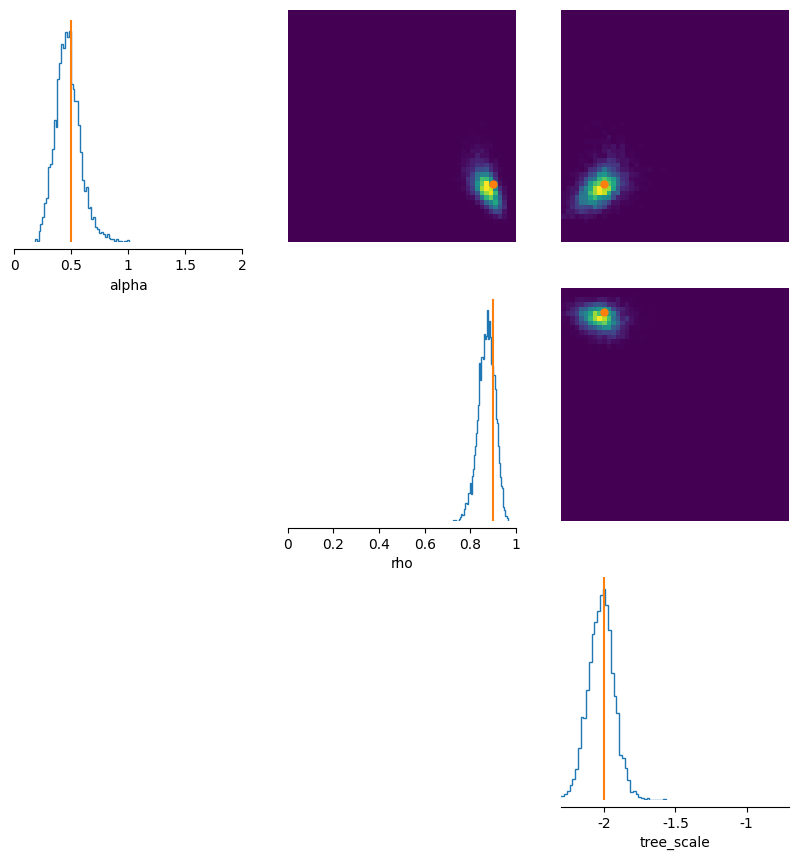

In [ ]:
true_params = theta_0.numpy()  # shape (1, 3)

true_params = torch.tensor([[0.5, 0.9, np.log10(0.01)]])  # shape (1, 3)
# simulate with true parameters to get features for visualization
true_stats = simulate(true_params).squeeze() # shape (num_features,)
# samples = posterior.sample((1000,), x=x_obs)
print(true_stats)
samples = posterior.sample((5000,), x=true_stats)

_ = pairplot(samples.numpy(),
             points=true_params,

             limits=[[0, 2], [0, 1], [np.log10(0.005), np.log10(0.2)]],
             labels=["alpha", "rho", "tree_scale"], show_titles=True)

In [53]:
# test accuracy of model on a new simulation
true_parameters = prior_dist.sample((200,))
infered_params = []

for i in true_parameters:
    features_test = simulate(i.unsqueeze(0))
    posterior_samples_test = posterior.sample((5000,), x=features_test, show_progress_bars=False)
    infered_params.append(posterior_samples_test.median(dim=0).values)

infered_params = torch.stack(infered_params)


In [54]:
# compute R^2 between true parameters (theta_test) and posterior samples median
# fore each parameter (alpha, rho, tree_scale)

R2_alpha = 1 - torch.sum((infered_params[:, 0] - true_parameters[:, 0]) ** 2) / torch.sum((true_parameters[:, 0] - true_parameters[:, 0].median()) ** 2)
R2_rho = 1 - torch.sum((infered_params[:, 1] - true_parameters[:, 1]) ** 2) / torch.sum((true_parameters[:, 1] - true_parameters[:, 1].median()) ** 2)
R2_tree_scale = 1 - torch.sum((infered_params[:, 2] - true_parameters[:, 2]) ** 2) / torch.sum((true_parameters[:, 2] - true_parameters[:, 2].median()) ** 2)

print("Test set R^2 (alpha):", R2_alpha)
print("Test set R^2 (rho):", R2_rho)
print("Test set R^2 (tree_scale):", R2_tree_scale)


Test set R^2 (alpha): tensor(0.8924)
Test set R^2 (rho): tensor(0.9235)
Test set R^2 (tree_scale): tensor(0.9509)


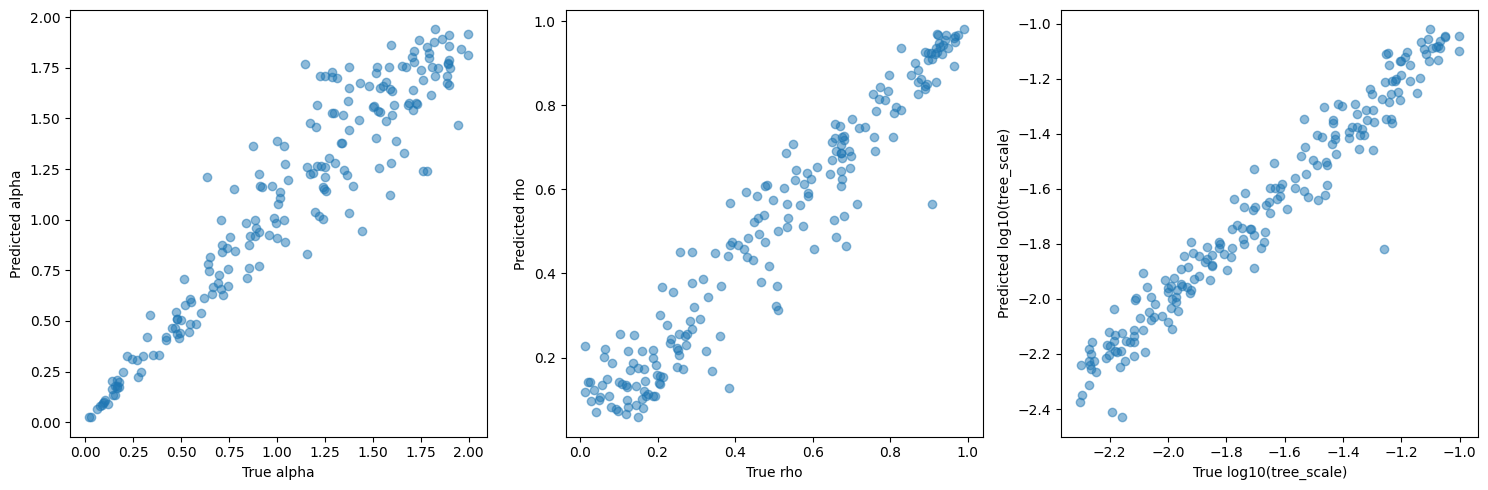

In [55]:
# scatter plot of true vs predicted parameters for test set
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.scatter(true_parameters[:, 0].numpy(), infered_params[:, 0].numpy(), alpha=0.5)
plt.xlabel("True alpha")
plt.ylabel("Predicted alpha")
plt.subplot(1, 3, 2)
plt.scatter(true_parameters[:, 1].numpy(), infered_params[:, 1].numpy(), alpha=0.5)
plt.xlabel("True rho")
plt.ylabel("Predicted rho")
plt.subplot(1, 3, 3)
plt.scatter(true_parameters[:, 2].numpy(), infered_params[:, 2].numpy(), alpha=0.5)
plt.xlabel("True log10(tree_scale)")
plt.ylabel("Predicted log10(tree_scale)")
plt.tight_layout()
plt.show()

In [21]:
empirical_msa = """
>Neomonachus_schauinslandi
ATGAGCGATGTTACCGTGGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAAAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAGGAGATGGATGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCGCATACTCTGACTGAGAGCAGAGTATTAAAGAACACCAGACACCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTAAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCAGAATATCTGGCACCAGAGGTGTTAGAAGACAATGACTATGGCCGAGCCGTGGATTGGTGGGGCCTGGGGGTCGTCATGTATGAGATGATGTGTGGGAGGCTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCACTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGCGGGGGCCCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTCTCTGGAGTCAACTGGCAAGATGTTTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTTACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAAACTATTACAATAACTCCACCTGAAAAATATGACGAGGACGGCATGGACTGCGTGGACAACGAGCGGCGGCCGCACTTCCCTCAGTTCTCCTACTCCGCCAGCGGCCGCGAG
>Phascolarctos_cinereus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAGGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTTAACAACTTTTCAGTGGCAAAAGAATGCCAACTCATGAAAACAGAACGACCAAAGCCAAATACATTTATTATCAGATGCCTCCAGTGGACCACTGTTATAGAACGAACATTTCATGTGGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTTCAGAGGCAAGAAGAAGAGAGAATGAAC---TGTAGTCCGACTTCACAAATTGATAATATAGGAGAGGAGGAAATGGATGCTTCTACAACTCATCATAAAAGAAAG---ACAATGAATGACTTTGACTATTTGAAACTGTTGGGTAAAGGCACTTTTGGAAAAGTGATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTTTGAAGAAAGAAGTAATTATTGCAAAGGATGAAGTGGCACATACTCTAACAGAAAGCAGAGTATTAAAAAACACTAGGCACCCCTTTTTAACTTCTTTGAAATATTCCTTCCAGACAAAAGATCGTTTGTGTTTTGTGATGGAGTATGTTAATGGAGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGCTTCTATGGTGCAGAAATTGTCTCAGCTTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAAAATTTGATGTTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATTACAGATGCAGCTACGATGAAGACATTTTGTGGTACACCTGAGTACCTTGCACCTGAGGTATTAGAAGATAATGACTATGGCCGTGCAGTAGACTGGTGGGGCCTGGGGGTTGTCATGTATGAAATGATGTGTGGGAGATTACCATTCTACAACCAGGATCATGAGAAACTTTTTGAGCTAATATTAATGGAGGACATTAAATTTCCTCGAACTCTTTCTTCTGATGCAAAATCCTTACTTTCAGGACTCTTAATAAAAGATCCAAATAAACGCCTTGGCGGAGGTCCAGATGATGCAAAAGAAATTATGAGGCATAGTTTCTTTGTTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTGGTACCTCCTTTTAAACCTCAAGTAACGTCTGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACAATTACAATAACACCGCCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGACGGCCACATTTCCCACAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Elephas_maximus_indicus
---------------------------------------------------------------------------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCTCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACGGTTATAGAGAGGACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACCGAAGCGATCCAGGCCGTAGCAGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGCCCAACTTCACAGATTGATAACATTGGGGAGGAAGAGATGGATGCCTCTACAACACATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCCCACACTCTAACTGAAAGCAGAGTATTAAAGAATACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAGGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGTACACCAGAATACCTGGCACCAGAGGTGTTAGAAGATAACGACTATGGTCGGGCAGTGGACTGGTGGGGCCTCGGTGTTGTCATGTATGAAATGATGTGTGGGAGGCTACCCTTCTACAACCAGGACCACGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACGCTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTGTTAATAAAGGATCCAAATAAACGGCTTGGTGGTGGACCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACAATTACAATAACACCACCTGAAAAATATGACGAGGATGGCATGGACTGCGTGGACAATGAGAGGCGGCCACATTTCCCTCAGTTTTCTTACTCTGCAAGTGGACGAGAA
>Orcinus_orca
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGACACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTCCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAAGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCCAAGGATGAAGTGGCACACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGAGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGTACACCGGAATATCTGGCACCAGAGGTGTTGGAAGATAATGACTATGGCCGAGCCGTGGATTGGTGGGGCCTTGGGGTTGTCATGTATGAAATGATGTGCGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATACTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAGTATGATGAGGACGGTATGGACTGCACGGACAGTGAGAGGCGGCCGCATTTCCCTCAGTTTTCCTACTCTGCAAGCGGACGAGAA
>Pteropus_vampyrus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTCATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGGCAAGAAGAGGAGAGAATGAAC---TGTAGTCCAACTTCACAAATTGATAACATAGGGGAGGAAGAGATGGATGCTTCTACAACTCATCATAAAAGAAAG---ACTATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATATTATGCAATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGCGAGAGCGGGTGTTCTCTGAGGACCGCACACGCTTCTACGGAGCAGAGATTGTCTCTGCCTTGGACTATCTGCATTCCGGGAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACGGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGTACACCAGAATACCTGGCGCCAGAGGTGTTGGAAGATAATGACTACGGCCGGGCAGTGGACTGGTGGGGCCTTGGCGTCGTCATGTATGAGATGATGTGTGGGAGATTGCCTTTCTACAACCAGGATCACGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCGTTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTCTCTGGAGTAAACTGGCAAGATGTATATGACAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCCGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATACGACGAGGACGGCATGGACTGCGTGGACAGCGAGCGGCGGCCGCACTTCCCCCAGTTTTCCTACTCGGCCAGCGGACGCGAA
>Rousettus_aegyptiacus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAGCGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGGCAAGAAGAAGAGAGAATGAAC---TGTAGTCCAACTTCACAGATTGATAACATAGGGGAGGAAGAGATGGACGCTTCTACAACTCATCATAAAAGAAAG---ACTATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATATTATGCAATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCGCACACTCTAACCGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGCGAGAGCGGGTGTTCTCCGAGGACCGCACGCGCTTCTATGGAGCAGAGATTGTCTCTGCCTTGGACTATCTGCATTCCGGGAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACGGATTTTGGACTTTGCAAAGAAGGGATCACAGACGCAGCCACCATGAAGACGTTCTGTGGCACACCAGAGTACCTGGCGCCAGAGGTGTTGGAAGATAATGACTACGGCCGGGCAGTGGACTGGTGGGGCCTCGGCGTCGTCATGTATGAGATGATGTGTGGGAGGTTGCCTTTCTACAACCAGGATCACGAGAAACTTTTCGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGCGGGGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTCTCCGGAGTAAACTGGCAAGATGTATATGACAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCCGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCGGAAAAATACGACGAGGACGGCATGGACTGCGTGGACAGCGAGCGGCGGCCGCACTTCCCCCAGTTCTCCTACTCCGCCAGCGGACGCGAA
>Pteropus_alecto
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGGCAAGAAGAGGAGAGAATGAAC---TGTAGTCCAACTTCACAGATTGATAACATAGGGGAGGAAGAGATGGATGCTTCTACAACTCATCATAAAAGAAAG---ACTATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATATTATGCAATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACATACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGCGAGAGCGGGTGTTCTCTGAGGACCGCACACGCTTCTACGGAGCAGAGATTGTCTCTGCCTTGGACTATCTGCATTCCGGGAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACGGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGTACACCAGAATATCTGGCGCCAGAGGTGTTGGAAGATAATGACTATGGCCGGGCAGTGGACTGGTGGGGCCTTGGCGTCGTCATGTATGAGATGATGTGTGGGAGATTGCCTTTCTACAACCAGGATCACGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCGTTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTCTCTGGAGTAAACTGGCAAGATGTATATGACAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCCGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATACGACGAGGACGGCATGGACTGCGTGGACAGCGAGCGGCGGCCGCACTTCCCCCAGTTTTCCTACTCGGCCAGCGGACGCGAA
>Echinops_telfairi
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCTCTCAACAACTTTTCAGTGGCAAAG---TGCCAGTTAATGAAAACAGAACGACCAAAACCAAATACATTTATTATCAGATGTCTCCAGTGGACCACCGTTATAGAGAGGACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCTGACAGACTGCAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACCTCACAAATAGATAATATAGGGGAGGAAGAAATGGATGCATCTACAACACATCATAAAAGAAAG---ACTATGAATGATTTTGACTATTTGAAACTGTTAGGTAAAGGCACTTTTGGGAAAGTCATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAAATTCTCAAGAAAGAAGTTATTATCGCAAAGGATGAAGTGGCACATACCCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGATCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTATACCGGGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGACACATAAAAATTACAGATTTTGGGCTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGCACACCAGAGTATCTGGCACCAGAGGTATTAGAAGATAATGACTATGGTCGAGCAGTGGACTGGTGGGGCCTAGGAGTTGTCATGTATGAGATGATGTGTGGGAGGTTACCTTTCTACAATCAGGACCATGAGAAACTTTTTGAACTGATACTAATGGAGGACATTAAATTCCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTAATAAAGGATCCAAATAAGCGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAATTGGCAAGATGTATATGATAAAAAGCTTTTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACAATTACAATAACACCACCTGAAAAATACGATGAGGATGGAATGGACTGCATCGACAGCGAGAGGCGGCCTCACTTCCCTCAGTTCTCCTACTCCGCAAGCGGCCGAGAA
>Dasypus_novemcinctus
ATGAGCGATGTCACCATCGTG------------------------AAGGAAGGCTGGGTACAGAAG---------GGAGAATATATAAAAAACTGGAGGCCACGGTATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTCGATCTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGGCCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCCGTAGCAGACAGACTACAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACGTCCCAAATTGATAACATAGGGGAGGAAGAGATGGATGCTTCCACAACTCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGTAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCCGAGTTTTAAAGAACACTAGACATCCCTTTTTAACCTCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCATATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGACGCAGCCACCATGAAAACGTTCTGTGGTACACCAGAATATCTGGCCCCAGAGGTGTTAGAAGACAACGACTACGGCCGCGCAGTGGACTGGTGGGGCCTCGGGGTCGTCATGTATGAGATGATGTGTGGCAGGCTGCCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATATTAATGGAGGATATTAAATTCCCTCGAACACTCTCTTCAGACGCAAAGTCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGCGGAGGACCTGATGATGCAAAAGAAATTATGAGACACAGCTTCTTTTCCGGAGTAAACTGGCAGGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAAACAGACACCAGATATTTTGATGAAGAATTCACAGCTCAGACGATTACAATAACACCTCCTGAAAAATACGACGAGGATGGCATGGACTGCGCCGACAGCGAGCGGCGGCCGCACTTCCCCCAGTTCTCCTACTCGGCCAGCGGCCGCGAG
>Lipotes_vexillifer
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGACACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTCCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAAGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCCAAGGATGAAGTGGCACACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGAGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACACTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGTACACCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCCGTGGATTGGTGGGGCCTTGGGGTTGTCATGTATGAAATGATGTGCGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCGAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATACTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAGTATGATGAGGACGGTATGGACTGCACGGACAGTGAGAGGCGGCCGCACTTCCCTCAGTTTTCCTACTCTGCAAGCGGACGAGAA
>Neophocaena_asiaeorientalis_asiaeorientalis
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGACACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTCCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAAGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAGGAAGTTATTATTGCCAAGGATGAAGTGGCACACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGAGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGTCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGTACACCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCCGTGGATTGGTGGGGCCTTGGGGTTGTCATGTATGAAATGATGTGCGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATACTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAGTATGATGAGGACGGTATGGACTGCACGGACAGTGAGAGGCGGCCGCACTTCCCTCAGTTTTCCTACTCTGCAAGCGGACGAGAA
>Phocoena_sinus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGACACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTCCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAAGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAGGAAGTTATTATTGCCAAGGATGAAGTGGCACACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGAGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGTCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGTACACCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCCGTGGATTGGTGGGGCCTTGGGGTTGTCATGTATGAAATGATGTGCGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATACTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAGTATGATGAGGACGGTATGGACTGCACGGACAGTGAGAGGCGGCCGCACTTCCCTCAGTTTTCCTACTCTGCAAGCGGACGAGAA
>Acinonyx_jubatus
ATGAGCGATGTCACCATCGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCGAGATACTTCCTTTTGAAGACAGATGGCTCATTCATTGGATATAAAGAGAAGCCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAACATAGGGGAGGAAGAGATGGACGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGAAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTCACTGAGAGCAGAGTGTTAAAGAACACTAGACACCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATTACAGATGCGGCCACCATGAAGACGTTCTGTGGAACACCAGAATATCTGGCACCAGAGGTGTTAGAAGACAATGACTATGGCCGAGCCGTGGATTGGTGGGGACTAGGGGTCGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGGACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTTTCTGGAGTTAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGACGAGGACGGCATGGATGGTGTGGACAGCGAGCGGCGGCCACATTTCCCTCAGTTCTCCTACTCTGCCAGCGGCCGGGAA
>Hyaena_hyaena
ATGAGCGATGTCACCATCGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCGAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAGCCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAAAGAACGTTTCATGTAGACACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAC---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAAGAGATGGACGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGAAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTTTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTCACTGAGAGCAGAGTGTTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAGTATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCGGCCACCATGAAGACATTCTGTGGAACACCAGAGTACCTGGCACCAGAGGTGTTAGAAGACAATGACTATGGCCGAGCCGTGGATTGGTGGGGACTAGGGGTCGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGGACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGCGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTTAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGACGAAGACGGCATGGACGGCGTGGACAGCGAGAGGCGGCCACACTTCCCTCAGTTCTCCTACTCTGCCAGCGGCCGGGAA
>Leopardus_geoffroyi
ATGAGCGATGTCACCATCGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCGAGATACTTCCTTTTGAAGACAGATGGCTCATTCATTGGATATAAAGAGAAGCCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAACATAGGGGAGGAAGAGATGGACGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGAAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTCACTGAGAGCAGAGTGTTAAAGAACACTAGACACCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATTACAGATGCGGCCACCATGAAGACGTTCTGTGGAACACCAGAATATCTGGCACCAGAGGTGTTAGAAGACAATGACTATGGCCGAGCCGTGGATTGGTGGGGACTAGGGGTCGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGGACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTTTCTGGAGTTAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGACGAGGACGGCATGGATGGTGTGGACAGCGAGCGGCGGCCACATTTCCCTCAGTTCTCCTACTCTGCCAGCGGCCGGGAA
>Lynx_canadensis
ATGAGCGATGTCACCATCGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCGAGATACTTCCTTTTGAAGACAGATGGCTCATTCATTGGATATAAAGAGAAGCCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAACATAGGGGAGGAAGAGATGGACGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGAAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTCACTGAGAGCAGAGTGTTAAAGAACACTAGACACCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATTACAGATGCGGCCACCATGAAGACGTTCTGTGGAACACCAGAATATCTGGCACCAGAGGTGTTAGAAGACAATGACTATGGCCGAGCCGTGGATTGGTGGGGACTAGGGGTCGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGGACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTTTCTGGAGTTAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGACGAGGACGGCATGGATGGTGTGGACAGCGAGCGGCGGCCACATTTCCCTCAGTTCTCCTACTCTGCCAGCGGCCGGGAA
>Panthera_leo
ATGAGCGATGTCACCATCGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCGAGATACTTCCTTTTGAAGACAGATGGCTCATTCATTGGATATAAAGAGAAGCCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGCAGTCCAACTTCACAAATTGATAACATAGGGGAGGAAGAGATGGACGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGAAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTCACTGAGAGCAGAGTGTTAAAGAACACTAGACACCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGCGATCTC------AAGTTGGAGAATCTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATTACAGATGCGGCCACCATGAAGACGTTCTGTGGAACACCAGAATATCTGGCACCAGAGGTATTAGAAGACAATGACTATGGCCGAGCCGTGGATTGGTGGGGACTAGGGGTCGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGGACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTTTCTGGAGTTAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGACGAGGACGGCATGGACGGTGTGGACAGCGAGCGGCGGCCACATTTCCCTCAGTTCTCCTACTCGGCCAGCGGCCGGGAA
>Panthera_pardus
ATGAGCGATGTCACCATCGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCGAGATACTTCCTTTTGAAGACAGATGGCTCATTCATTGGATATAAAGAGAAGCCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCGAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGCAGTCCAACTTCACAAATTGATAACATAGGGGAGGAAGAGATGGACGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGAAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTCACTGAGAGCAGAGTGTTAAAGAACACTAGACACCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGCGATCTC------AAGTTGGAGAATCTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATTACAGATGCGGCCACCATGAAGACGTTCTGTGGAACACCAGAATATCTGGCACCAGAGGTATTAGAAGACAATGACTATGGCCGAGCCGTGGATTGGTGGGGACTAGGGGTCGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGGACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTTTCTGGAGTTAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGACGAGGACGGCATGGACGGTGTGGACAGTGAGCGGCGGCCACATTTCCCTCAGTTCTCCTACTCGGCCAGCGGCCGGGAA
>Panthera_tigris
ATGAGCGATGTCACCATCGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCGAGATACTTCCTTTTGAAGACAGATGGCTCATTCATTGGATATAAAGAGAAGCCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGGCTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGCAGTCCAACTTCACAAATTGATAACATAGGGGAGGAAGAGATGGACGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGAAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTCACTGAGAGCAGAGTGTTAAAGAACACTAGACACCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATTACAGATGCGGCCACCATGAAGACGTTCTGTGGAACACCAGAATATCTGGCACCAGAGGTATTAGAAGACAATGACTATGGCCGAGCCGTGGATTGGTGGGGACTAGGGGTCGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGGACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTTTCTGGAGTTAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGACGAGGACGGCATGGACGGTGTGGACAGCGAGCGGCGGCCACATTTCCCTCAGTTCTCCTACTCGGCCAGCGGCCGGGAA
>Panthera_uncia
ATGAGCGATGTCACCATCGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCGAGATACTTCCTTTTGAAGACAGATGGCTCATTCATTGGATATAAAGAGAAGCCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGCAGTCCAACTTCACAGATTGATAACATAGGGGAGGAAGAGATGGACGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTGCTAGGTAAAGGCACTTTTGGAAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTCACTGAGAGCAGAGTGTTAAAGAACACTAGACACCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATTACAGATGCGGCCACCATGAAGACGTTCTGTGGAACACCAGAATATCTGGCACCAGAGGTATTAGAAGACAATGACTATGGCCGAGCCGTGGATTGGTGGGGACTAGGGGTCGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGGACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTTTCTGGAGTTAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGACGAGGACGGCATGGACGGTGTGGACAGCGAGCGGCGGCCACATTTCCCTCAGTTCTCCTACTCGGCCAGCGGCCGGGAA
>Prionailurus_bengalensis
ATGAGCGATGTCACCATCGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCGAGATACTTCCTTTTGAAGACAGATGGCTCATTCATTGGATATAAAGAGAAGCCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGCCCAACTTCACAAATTGATAACATAGGGGAGGAAGAGATGGACGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGAAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTCACTGAGAGCAGAGTGTTAAAGAACACTAGACACCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATTACAGATGCGGCCACCATGAAGACGTTCTGTGGAACACCAGAATATCTGGCACCAGAGGTGTTAGAAGACAATGACTATGGCCGAGCCGTGGATTGGTGGGGACTAGGGGTCGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAGCTAATACTAATGGAAGACATTAAATTTCCTCGGACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTTTCTGGAGTTAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGACGAGGACGGCATGGATGGTGTGGACAGCGAGCGGCGGCCACATTTCCCTCAGTTCTCCTACTCTGCCAGCGGCCGGGAA
>Puma_concolor
ATGAGCGATGTCACCATCGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCGAGATACTTCCTTTTGAAGACAGATGGCTCATTCATTGGATATAAAGAGAAGCCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAACATAGGGGAGGAAGAGATGGACGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGAAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTCACTGAGAGCAGAGTGTTAAAGAACACTAGACACCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATTACAGATGCGGCCACCATGAAGACGTTCTGTGGAACACCAGAATATCTGGCACCAGAGGTGTTAGAAGACAATGACTATGGCCGAGCCGTGGATTGGTGGGGACTAGGGGTCGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGGACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTTTCTGGAGTTAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGACGAGGACGGCATGGATGGTGTGGACAGCGAGCGGCGGCCACATTTCCCTCAGTTCTCCTACTCTGCCAGCGGCCGGGAA
>Puma_yagouaroundi
ATGAGCGATGTCACCATCGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCGAGATACTTCCTTTTGAAGACAGATGGCTCATTCATTGGATATAAAGAGAAGCCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAACATAGGGGAGGAAGAGATGGACGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAACGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGAAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTCACTGAGAGCAGAGTGTTAAAGAACACTAGACACCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATTACAGATGCGGCCACCATGAAGACGTTCTGTGGAACACCAGAATATCTGGCACCAGAGGTGTTAGAAGACAATGACTATGGCCGAGCCGTGGATTGGTGGGGACTAGGGGTCGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGGACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTTTCTGGAGTTAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGACGAGGACGGCATGGATGGTGTGGACAGCGAGCGGCGGCCGCATTTCCCTCAGTTCTCCTACTCTGCCAGCGGCCGGGAA
>Suricata_suricatta
------GATGTCACCATCGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCGAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAGCCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAAAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAC---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAAGAGATGGACGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGAAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTCACTGAGAGCAGAGTGTTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACGCGCTTCTACGGCGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATCGTGTACCGTGATCTC------AAGTTGGAGAATCTGATGCTGGATAAAGATGGCCACATAAAAATTACAGACTTTGGACTCTGCAAAGAAGGGATCACAGACGCGGCCACCATGAAGACATTCTGTGGCACACCAGAGTATCTGGCACCAGAGGTGTTAGAAGACAATGACTATGGCCGAGCTGTGGATTGGTGGGGACTAGGGGTCGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTCGAACTAATACTAATGGAAGACATTAAATTTCCTCGGACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTTTCTGGAGTTAACTGGCAAGACGTATATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGACGAGGACGGCATGGACGGCGTGGACAGCGAGCGGCGGCCGCACTTCCCTCAGTTCTCCTACTCTGCCAGTGGCCGGGAG
>Antechinus_flavipes
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAGGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTTAACAACTTTTCAGTGGCAAAA---TGCCAGCTCATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGCCTCCAGTGGACCACTGTTATAGAACGAACATTTCATGTGGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTTCAGAGGCAAGAAGAGGAAAGGATGAAT---TGTAGTCCTACTTCACAAATTGACAATATAGGAGAAGAGGAAATGGATGCTTCTACAACTCATCATAAAAGAAAG---ACAATGAATGACTTTGACTATTTGAAACTATTGGGTAAAGGCACTTTTGGGAAAGTGATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTTTGAAGAAAGAAGTAATTATTGCAAAGGATGAAGTGGCACATACTCTAACAGAAAGTAGAGTTTTAAAAAACACGAGACACCCATTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGATCGTTTGTGTTTTGTGATGGAGTATGTTAATGGAGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGCTTCTATGGTGCAGAAATTGTCTCCGCTTTGGACTATCTACATTCCGGAAAAATTGTGTACCGTGATCTC------AAGTTGGAAAATTTGATGTTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGTAAAGAAGGGATTACAGATGCAGCTACGATGAAGACGTTTTGTGGTACACCTGAATACCTTGCACCTGAGGTCTTAGAAGACAATGACTATGGCCGTGCAGTAGACTGGTGGGGTCTGGGCGTTGTCATGTATGAAATGATGTGTGGGAGATTGCCATTCTACAACCAGGATCATGAGAAGCTTTTTGAGCTAATACTAATGGAGGACATTAAATTTCCTCGAACTCTTTCTTCTGATGCAAAATCCTTACTTTCTGGACTCTTAATAAAAGATCCAAATAAACGCCTTGGTGGAGGTCCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTTGTTGGCATAAACTGGCAAGATGTGTATGATAAAAAGCTGGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACAATTACAATAACACCGCCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGACGGCCACATTTCCCACAGTTTTCCTACTCAGCAAGTGGACGAGAA
>Monodelphis_domestica
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAGGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTTAACAACTTTTCAGTGGCAAAA---TGCCAGCTCATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGCCTCCAGTGGACCACTGTTATAGAACGAACATTTCATGTGGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTTCAGAGGCAAGAAGAGGAAAGGATGAAC---TGTAGTCCAACTTCACAAATTGACAATATAGGAGAAGAGGAAATGGATGCTTCTACAACTCATCATAAAAGAAAG---ACAATGAATGACTTTGACTATTTGAAATTATTGGGTAAAGGCACTTTTGGGAAAGTGATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTTTGAAGAAAGAAGTAATTATTGCAAAGGATGAAGTGGCACACACTCTAACAGAAAGCAGAGTATTAAAAAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCTTTCCAGACAAAAGATCGTTTGTGTTTTGTGATGGAGTATGTTAATGGAGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGCTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCTGGAAAGATTGTGTATCGTGATCTC------AAGTTGGAAAATTTGATGTTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATTACAGATGCAGCTACAATGAAGACATTTTGTGGTACACCTGAATACCTTGCACCTGAGGTATTAGAAGATAATGACTATGGCCGTGCAGTGGACTGGTGGGGTTTGGGGGTTGTCATGTATGAAATGATGTGTGGGAGATTACCATTCTACAACCAGGATCATGAGAAACTTTTTGAGCTAATACTAATGGAGGACATTAAATTTCCTCGAACTCTTTCTTCTGATGCAAAATCCTTACTTTCAGGACTCTTAATAAAAGATCCAAATAAACGCCTTGGTGGAGGTCCGGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTTGTTGGAGTAAATTGGCAAGATGTATATGATAAAAAGCTGGTACCTCCTTTTAAGCCTCAAGTAACGTCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAAACAATTACAATAACTCCACCTGAAAAATATGATGAAGATGGTATGGACTGCATGGACAATGAGAGACGGCCACATTTTCCACAGTTTTCCTACTCAGCAAGTGGACGAGAA
>Trichosurus_vulpecula
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAGGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTTAACAACTTTTCAGTGGCAAAA---TGCCAGCTTATGAAAACAGAACGACCAAAGCCAAATACATTTATTATCAGATGCCTCCAGTGGACCACTGTTATAGAACGAACATTTCATGTGGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTTCAGAGGCAAGAAGAGGAGAGGATGAAC---TGTAGTCCGACTTCACAAATTGACAATATAGGAGAGGAGGAAATGGATGCTTCTACAACACATCATAAAAGAAAG---ACAATGAATGACTTTGACTATTTGAAACTACTGGGTAAAGGCACTTTTGGGAAAGTGATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTTTGAAGAAAGAAGTAATTATTGCAAAGGATGAAGTGGCACATACTCTAACAGAAAGCAGAGTATTAAAAAACACTAGGCACCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGATCGTTTGTGTTTTGTGATGGAGTATGTTAATGGAGGGGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGCTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAAAATTTGATGTTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCGGCTACAATGAAGACATTTTGTGGTACACCTGAGTACCTTGCACCTGAGGTATTAGAAGATAATGACTATGGTCGTGCGGTGGACTGGTGGGGTTTGGGGGTTGTCATGTATGAAATGATGTGTGGGAGATTACCATTCTACAACCAGGATCATGAGAAACTTTTTGAGCTAATACTAATGGAGGACATTAAATTTCCTCGAACTCTTTCTTCTGATGCAAAATCCTTACTTTCAGGACTCTTAATAAAAGATCCAAATAAACGCCTTGGCGGAGGTCCAGATGATGCAAAAGAAATTATGAGGCATAGTTTCTTTGTTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTGGTACCTCCTTTTAAACCTCAAGTAACGTCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACAATTACAATAACACCGCCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGACGGCCACATTTCCCACAGTTTTCCTACTCAGCAAGTGGACGAGAA
>Tachyglossus_aculeatus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGACCAAGATACTTCCTTTTGAAGACAGATGGCTCCTTCATAGGATACAAGGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAATTTTTCCGTGGCAAAG---TGCCAGCTAATGAAAACAGAACGCCCAAAGCCAAACACATTTATTATCCGATGTCTCCAATGGACCACTGTCATAGAAAGAACATTTCATGTGGATACTCCAGAGGAAGAAGAATGGACAGAAGCCATCCAGGGTGTAGCAGACAGACTTCAGAGACAAGAAGAAGAGAGAATGAAT---TGCAGTCCAACGTCCCAGATTGACAACATAGGGGAGGAGGAGATGGATGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTGGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAAAAAGCAAGTGGGAAATATTATGCTATGAAGATTTTGAAGAAAGAAGTTATTATTGCAAAGGACGAAGTGGCACACACTCTCACAGAAAGCAGAGTACTAAAGAACACTAGACATCCCTTTTTAACGTCTTTGAAATATTCCTTCCAGACAAAAGATCGGTTGTGTTTTGTGATGGAATACGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAACGGGTGTTCTCTGAGGACCGCACACGCTTCTACGGTGCAGAGATTGTCTCCGCTCTGGACTATCTGCATTCCGGAAAGATTGTGTACCGGGATCTC------AAGCTGGAGAATTTGATGTTGGATAAAGACGGTCACATAAAAATTACGGATTTTGGACTTTGCAAAGAGGGGATCACTGACGCGGCTACCATGAAGACGTTCTGTGGGACACCAGAATACCTGGCACCAGAGGTCTTAGAAGACAATGACTACGGCCGGGCAGTGGATTGGTGGGGCCTCGGGGTTGTCATGTATGAAATGATGTGCGGGAGATTGCCATTCTACAACCAGGATCACGAGAAACTTTTTGAACTGATTCTAATGGAGGATATTAAATTCCCCCGGACGCTCTCTTCAGATGCAAAATCATTGCTTTCAGGACTCCTAATAAAGGACCCTAATAAACGCCTTGGTGGAGGTCCAGATGATGCGAAAGAAATTATGAGGCACAGTTTCTTTGTCGGACTAAACTGGCAAGATGTATATGATAAAAAGCTGGTACCGCCTTTTAAACCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACAATTACCATAACACCTCCAGAAAAATATGACGAGGATGGGATGGACTGCGTGGACAACGAGAGGCGGCCGCACTTCCCCCAGTTCTCCTACTCGGCCAGCGGACGAGAG
>Cebus_imitator
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGGACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTACAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGCCCAACTTCACAAATTGATAACATAGGGGAAGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTGCTAGGTAAAGGCACTTTTGGGAAAGTCATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATCCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACGCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGCGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTTTACCGTGATCTTAATACACAGTTGGAGAATCTAATGCTGGATAAAGATGGCCACATAAAAATTACAGACTTTGGACTTTGCAAGGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGTACTCCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTCGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTCGAACTCATATTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCGAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGATACTAGATATTTTGATGAGGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAATTTTCCTACTCTGCAAGTGGACGAGAA
>Cricetulus_griseus
ATGAGCGATGTTACCATTGTG------------------------AAGGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAATTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGTTCATTCATAGGCTATAAAGAAAAACCTCAAGATGTGGACTTACCTTATCCCCTCAACAACTTTTCCGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAATACATTTATTATCAGATGTCTTCAATGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACCGACTGCAGAGGCAAGAAGAGGAGAGGATGAAT---TGTAGTCCAACTTCACAAATTGATAACCTAGGGGAGGAAGAGATGGATGCGTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAGGTTATTTTAGTTCGAGAAAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTTACTGAGAGCAGAGTACTAAAGAACACCAGACATCCATTCTTAACATCCTTGAAATATTCCTTCCAGACAAAAGATCGCCTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAACGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCATATAAAAATTACAGATTTTGGACTTTGCAAAGAGGGAATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCAGAGTATCTGGCCCCAGAGGTATTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTGGGTGTTGTCATGTATGAAATGATGTGTGGGAGGTTGCCTTTCTACAACCAGGATCATGAGAAACTCTTTGAACTAATACTAATGGAAGACATTAAATTTCCCCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCCAATAAACGCCTTGGTGGAGGGCCAGATGATGCAAAAGAAATCATGAGGCATAGTTTCTTTTCTGGTGTAAACTGGCAAGATGTATACGACAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAAACTATTACAATAACACCACCTGAAAAATATGACGAAGACGGCATGGAGTGCATGGACAACGAGCGGCGGCCACACTTCCCTCAGTTCTCCTACTCTGCGAGTGGACGGGAG
>Microtus_oregoni
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAATTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGTTCATTCATAGGCTATAAAGAGAAACCTCAAGATGTGGACTTACCTTATCCCCTCAACAACTTTTCTGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAATACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAAGCTGTAGCAGACCGACTGCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAGATTGATAATATAGGAGAAGAAGAGATGGATGCATCTACAACCCATCATAAAAGAAAG---ACGATGAATGATTTTGACTATTTGAAGCTACTAGGTAAAGGCACTTTTGGGAAGGTTATTTTAGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTTACTGAAAGCAGAGTACTAAAGAACACCAGACATCCATTCTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTCTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCATATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGAATCACAGATGCAGCCACCATGAAGACATTCTGTGGTACCCCAGAATATCTGGCACCAGAGGTATTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTGGGTGTTGTCATGTATGAAATGATGTGTGGGAGGTTGCCTTTCTACAACCAGGATCATGAGAAACTCTTTGAACTAATACTAATGGAAGACATTAAATTTCCCCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGGCCAGATGATGCAAAAGAAATTATGAGGCATAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTACGACAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACAAGATATTTTGATGAAGAATTTACAGCTCAAACTATTACAATAACACCACCTGAAAAATATGATGAAGATGGCATGGAGTGCATGGACAACGAGCGGCGGCCACATTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Balaenoptera_acutorostrata_scammoni
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGACACTCCAGAGGAA------------------------------------------------------------------------------------------------------------------------------------------------------ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAAGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCCAAGGATGAAGTGGCACACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGTACACCAGAGTATCTGGCCCCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCCGTGGATTGGTGGGGCCTTGGGGTTGTCATGTATGAAATGATGTGCGGGAGATTACCTTTCTATAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATACTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAGTATGATGAGGACGGTATGGATTGCATGGACAATGAGAGGCGGCCGCACTTCCCTCAGTTCTCCTACTCCGCGAGCGGGCGAGAA
>Jaculus_jaculus
ATGAGCGATGTTACCATTGTA------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGCTATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTCTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATCATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAGCTACTAGGTAAAGGCACTTTTGGGAAAGTGATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACATTGACAGAAAGCAGAGTGCTGAAGAACACTAGGCATCCATTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTTTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAAAATTTGATGCTGGATAAAGATGGCCATATAAAAATTACAGATTTTGGTCTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGTACACCAGAATATCTGGCACCAGAGGTATTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGATATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCTAATAAACGCCTTGGTGGAGGACCTGATGATGCAAAAGAAATCATGAGACACAGTTTCTTTTCTGGAATAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACGAGATATTTTGATGAAGAATTCACAGCCCAGACTATTACAATAACACCACCTGAAAAATATGACGAAGATGGCATGGATGGCATGGACAATGAACGGCGGCCACACTTCCCTCAGTTCTCCTACTCTGCAAGTGGACGGGAA
>Rattus_rattus
ATGAGCGATGTTACCATCGTT------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAATTGGAGGCCAAGATACTTCCTTTTGAAGACAGACGGCTCATTCATAGGCTATAAGGAGAAACCTCAAGATGTGGACTTACCTTATCCCCTCAACAACTTCTCAGTGGCAAAA---TGTCAATTAATGAAAACAGAACGACCAAAGCCAAATACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAAGCTGTAGCCGATCGACTGCAGAGGCAAGAAGAGGAGAGGATGAAT---TGTAGTCCAACGTCACAGATTGATAATATTGGAGAGGAAGAGATGGACGCATCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTGCTAGGTAAAGGCACTTTTGGGAAGGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTACGCTATGAAGATTCTGAAGAAAGAAGTCATTATCGCAAAGGATGAAGTGGCACATACTCTGACTGAGAGCAGAGTTCTAAAGAACACCAGACATCCATTTCTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCTGGAAAGATTGTGTACCGAGATCTC------AAGTTGGAGAATTTGATGCTAGATAAGGATGGCCATATAAAAATTACGGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCTACCATGAAGACATTCTGTGGTACACCAGAGTATCTGGCACCAGAGGTATTAGAAGATAATGACTATGGCCGAGCTGTGGACTGGTGGGGCCTAGGTGTTGTCATGTATGAAATGATGTGTGGGAGGTTGCCTTTCTACAACCAGGATCATGAGAAACTCTTTGAACTAATACTAATGGAAGACATCAAATTCCCCCGAACACTCTCTTCAGATGCAAAGTCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGGCCAGATGATGCAAAAGAGATTATGAGGCACAGTTTCTTTTCTGGAGTAAACTGGCAGGACGTATATGACAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAGTATGACGACGACGGCATGGACTGCATGGATAATGAGCGGCGGCCACACTTCCCTCAGTTCTCCTACTCTGCAAGCGGACGGGAA
>Grammomys_surdaster
ATGAGCGATGTCACCATTGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAATTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGTTATAAGGAGAAACCCCAAGATGTGGACTTACCCTATCCCCTCAACAACTTCTCAGTGGCAAAA---TGTCAGTTAATGAAAACAGAGCGACCAAAGCCAAATACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACACCAGAGGAAGAAGAGTGGACAGAAGCTATCCAAGCTGTAGCTGACCGACTACAGAGGCAAGAAGAGGAGAGGATGAAT---TGTAGTCCAACCTCACAGATTGATAATATAGGAGAGGAAGAGATGGACGCGTCTACAACCCATCATAAAAGAAAG---ACTATGAATGATTTTGACTATCTAAAACTACTAGGTAAAGGGACTTTTGGGAAGGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTTACTGAAAGCAGAGTACTAAAGAACACCAGACATCCATTTTTAACATCATTGAAATATTCCTTCCAGACAAAAGATCGTTTGTGTTTTGTCATGGAATATGTTAATGGAGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTAGATAAGGATGGCCATATAAAAATTACGGATTTCGGACTTTGCAAAGAAGGGATCACAGATGCAGCTACCATGAAGACATTCTGTGGTACACCAGAATATCTGGCACCAGAGGTATTAGAAGATAATGACTATGGCCGAGCCGTGGACTGGTGGGGCCTAGGTGTGGTCATGTATGAAATGATGTGTGGGAGATTGCCTTTCTACAACCAGGATCATGAGAAACTCTTTGAATTAATACTAATGGAAGACATTAAATTCCCCCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCCTGATAAAGGATCCAAACAAGCGCCTTGGTGGAGGGCCAGATGATGCAAAAGAAATCATGAGGCATAGTTTTTTTTCTGGAGTAAACTGGCAAGATGTATATGACAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAAACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAGTATGACGATGACGGCATGGACTGCATGGACAACGAGCGGCGGCCCCACTTCCCTCAGTTCTCATACTCTGCAAGCGGACGGGAA
>Piliocolobus_tephrosceles
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTCTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAATTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCGGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACTCCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTTGAATTAATATTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGATACTAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGAGGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAGTTCTCCTACTCTGCAAGTGGACGAGAA
>Colobus_angolensis_palliatus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAATTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGGTGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCGGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACTCCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTTGAATTAATATTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGATACTAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGAGGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Rhinolophus_ferrumequinum
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCGCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGGACATTTCATGTAGATACCCCAGAGGAAGAAGAATGGACAGAAGCTATTCAGGCAGTAGCAGACAGACTTCAGAGGCAAGAAGAGGAGAGAATGAAC---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAAGAGATGGATGCTTCTACAACCCATCACAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGAAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAG---------------------------------------------------------------------------------------------------------------------------------------CTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGTACCCCAGAATATCTGGCTCCCGAGGTATTAGAAGATAATGACTATGGCCGAGCTGTGGATTGGTGGGGCCTAGGAGTTGTGATGTATGAAATGATGTGTGGGAGGTTACCTTTTTACAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGACATTAAATTTCCACGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGTCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTCTCTGGAGTAAACTGGCAAGATGTATACGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGATTGCATGGACAACGAGAGGCGGCCGCACTTCCCGCAGTTTTCCTACTCTGCAAGTGGACGCGAA
>Vicugna_pacos
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAAGAGATGGATGCTTCTACAACTCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTGCTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCCAAGGATGAAGTGGCACACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATACTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGTACACCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCCGTGGATTGGTGGGGCCTTGGGGTTGTTATGTATGAAATGATGTGTGGGCGGTTGCCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCAGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCAGAAAAATATGATGAGGACGGCATGGACTGCATGGACAATGAGAGACGGCCGCACTTCCCTCAGTTTTCCTACTCTGCAAGTGGCCGGGAA
>Camelus_bactrianus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAAGAGATGGATGCTTCTACAACTCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTGCTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCCAAGGATGAAGTGGCACACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATACTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGCGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGCACACCAGAGTATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCCGTGGATTGGTGGGGCCTTGGGGTTGTTATGTATGAAATGATGTGTGGGCGGTTGCCCTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCAGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCAGAAAAATATGATGAGGACGGCATGGACTGCATGGACAATGAGAGACGGCCGCACTTCCCTCAGTTTTCCTACTCTGCAAGTGGCCGGGAA
>Apodemus_sylvaticus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAATTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGCTATAAGGAGAAACCTCAAGATGTGGACTTACCTTATCCCCTCAACAACTTCTCAGTGGCAAAA---TGTCAGTTAATGAAAACAGAGCGACCAAAGCCAAATACATTTATTATCAGATGTCTTCAGTGGACCACTGTAATAGAGAGAACATTTCATGTAGATACACCAGAGGAAGAAGAATGGACAGAAGCTATCCAAGCTGTAGCCGACCGACTGCAGAGGCAAGAAGAAGAGAGGATGAAT---TGTAGTCCAACCTCACAGATTGATAATATAGGAGAGGAAGAGATGGATGCGTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACGTTTGGGAAGGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAAAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTTACTGAAAGCAGAGTACTAAAGAACACCAGACATCCATTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGATCGTTTGTGTTTTGTGATGGAATATGTTAATGGTGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTGATGCTAGATAAGGATGGCCATATAAAAATCACGGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCGGCTACCATGAAGACATTCTGTGGCACACCAGAGTATCTGGCACCAGAGGTATTAGAAGATAATGACTATGGTCGAGCTGTGGATTGGTGGGGCCTCGGTGTTGTCATGTATGAAATGATGTGTGGGAGGTTGCCTTTCTACAACCAGGATCATGAGAAACTCTTTGAATTAATACTAATGGAAGATATTAAATTCCCCCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGGCCCGATGATGCAAAGGAAATCATGAGGCATAGCTTTTTTTCTGGAGTAAACTGGCAAGATGTATACGACAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTCACATCTGAAACAGACACCAGATATTTTGATGAAGAATTCACAGCTCAGACTATTACAATAACACCACCTGAAAAGTATGACGATGACGGCATGGACGGCATGGATAACGAGCGGCGGCCACACTTCCCTCAGTTCTCCTACTCTGCAAGCGGACGCGAA
>Mus_caroli
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGTTCATTCATAGGCTATAAGGAGAAACCTCAAGATGTGGACTTACCTTATCCCCTCAACAACTTCTCAGTGGCAAAA---TGTCAGTTAATGAAAACAGAACGACCAAAGCCAAATACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACACCAGAGGAAGAAGAGTGGACGGAAGCTATCCAAGCCGTAGCCGATCGATTGCAGAGGCAAGAAGAGGAAAGGATGAAT---TGTAGTCCAACCTCACAGATTGATAATATAGGAGAAGAAGAGATGGATGCGTCTACAACCCATCATAAAAGAAAG---ACGATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTTACTGAAAGCAGAGTACTAAAGAACACCAGACATCCATTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGCGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTAGATAAGGATGGCCATATAAAAATTACGGATTTTGGGCTTTGCAAAGAAGGGATCACAGATGCAGCTACCATGAAGACATTCTGTGGCACACCAGAGTACCTGGCACCAGAGGTATTAGAAGATAATGACTATGGCCGAGCCGTGGACTGGTGGGGCTTAGGTGTTGTCATGTATGAAATGATGTGTGGAAGGTTGCCTTTCTACAACCAGGATCATGAGAAACTCTTTGAATTAATACTAATGGAAGACATTAAATTCCCCCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGGCCAGATGATGCAAAAGAAATCATGAGGCATAGTTTTTTTTCTGGAGTAAACTGGCAAGATGTATATGACAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAAACAGACACCCGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAGTATGACGACGACGGCATGGACGGCATGGACAACGAGCGGCGGCCACACTTCCCTCAGTTCTCCTACTCTGCAAGCGGACGGGAA
>Mus_musculus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGCTATAAGGAGAAACCTCAAGATGTGGACTTACCTTATCCCCTCAACAACTTCTCAGTGGCAAAA---TGTCAGTTAATGAAAACAGAACGACCAAAGCCAAATACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACACCAGAGGAAGAAGAGTGGACGGAAGCTATCCAAGCCGTAGCCGACCGATTGCAGAGGCAAGAGGAGGAGAGGATGAAT---TGTAGCCCAACCTCACAGATTGATAATATAGGAGAAGAAGAGATGGATGCGTCTACAACCCATCATAAAAGAAAG---ACGATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTTACTGAAAGCAGAGTACTAAAGAACACCAGACATCCATTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGCGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGAGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTAGATAAGGATGGCCATATAAAAATTACGGATTTTGGGCTTTGCAAAGAAGGGATCACAGATGCAGCTACCATGAAGACATTCTGTGGCACACCAGAGTACCTGGCACCAGAGGTATTAGAAGATAATGACTATGGCCGAGCCGTGGACTGGTGGGGCTTAGGTGTTGTCATGTATGAAATGATGTGTGGAAGGTTGCCTTTCTACAACCAGGATCATGAGAAACTCTTTGAATTAATACTAATGGAAGACATTAAATTCCCCCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGGCCAGATGATGCAAAAGAAATCATGAGGCATAGTTTTTTTTCTGGAGTAAACTGGCAAGATGTATATGACAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAAACAGACACCCGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAGTATGACGACGACGGCATGGACGGCATGGACAACGAGCGGCGGCCACACTTCCCTCAGTTCTCCTACTCTGCAAGCGGACGGGAA
>Mastomys_coucha
---------------------------------------------------------------------------GGAGAATATATAAAAAATTGGAGGCCAAGATACTTCCTTCTGAAGACAGATGGATCATTCATAGGCTACAAGGAGAAACCTCAGGATGTGGACTTACCTTATCCCCTCAACAACTTCTCAGTGGCAAAA---TGTCAGTTAATGAAAACAGAACGACCAAAGCCAAATACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACACCAGAAGAGGAAGAATGGACAGAAGCTATCCAAGCCGTAGCCGACCGACTGCAGAGGCAAGAAGAGGAGAGGATGAAT---TGTAGTCCAACCTCACAGATTGATAATATAGGAGAGGAAGAGATGGATGCATCCACAACCCATCATAAAAGAAAG---ACAATGAACGATTTTGACTATTTGAAACTACTAGGTAAAGGCACATTTGGGAAAGTGATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCTCACACTCTTACTGAAAGCAGAGTGCTAAAGAACACCAGGCATCCGTTTCTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGAGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGAACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAACTTGATGCTAGATAAGGATGGCCATATAAAGATTACGGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCTACCATGAAGACTTTCTGTGGTACACCAGAGTATCTGGCGCCAGAGGTATTAGAAGATAATGACTATGGCCGAGCCGTGGACTGGTGGGGCCTAGGTGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTCTTTGAATTAATACTAATGGAAGACATTAAATTCCCCCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGGCCAGATGATGCAAAAGAAATCATGAGGCATAGTTTTTTTTCTGGAGTAAACTGGCAAGATGTATACGACAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAAACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAGAAGTATGACGACGATGGCATGGATGGCATGGACAACGAGCGGCGGCCACACTTTCCTCAGTTCTCCTACTCAGCAAGTGGACGGGAA
>Mus_pahari
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGCTATAAGGAGAAACCTCAAGATGTGGACTTACCTTATCCCCTTAACAACTTCTCAGTGGCAAAA---TGTCAGTTAATGAAAACAGAACGACCAAAGCCAAATACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGACACACCAGAGGAAGAAGAATGGACAGAAGCTATCCAAGCCGTAGCTGACCGATTGCAGAGGCAAGAAGAGGAGAGGATGAAT---TGTAGTCCAACCTCACAGATTGATAATATAGGAGAGGAAGAGATGGATGCATCTACAACCCATCATAAGAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAAAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTTACTGAAAGCAGAGTACTAAAGAACACCAGACATCCATTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGTGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTAGATAAGGATGGCCATATAAAAATTACGGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCGACCATGAAGACATTCTGTGGTACACCAGAGTATCTGGCACCAGAGGTATTAGAAGATAATGACTATGGCCGAGCCGTGGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGAAGGTTGCCTTTCTACAACCAGGATCATGAGAAACTCTTTGAATTAATACTAATGGAAGACATTAAATTCCCCCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGGCCGGATGATGCAAAAGAAATCATGAGGCATAGTTTTTTTTCTGGAGTAAACTGGCAAGATGTATATGACAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAAACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAGTATGATGACGACGGCATGGATGGCATGGACAACGAGCGACGGCCACACTTCCCTCAGTTCTCCTACTCTGCCAGTGGACGGGAA
>Arvicanthis_niloticus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAATTGGAGGCCAAGATACTTCCTTTTGAAGACAGACGGCTCATTCATAGGCTATAAGGAGAAACCTCAAGATGTGGACTTACCCTATCCCCTCAACAACTTCTCAGTGGCAAAA---TGTCAGTTAATGAAAACAGAACGACCAAAGCCAAATACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACACCAGAGGAAGAAGAATGGACAGAGGCTATCCAAGCTGTAGCTGACCGACTACAGAGGCAAGAAGAGGAGAGGATGAAT---TGTAGTCCAACCTCACAGATTGATAATATAGGAGAGGAAGAGATGGATGCGTCTACAACCCATCATAAAAGAAAG---ACTATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAGGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTTACTGAAAGCAGAGTACTAAAGAACACCAGACATCCATTTTTAACATCATTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGAGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTAGACAAGGATGGACATATAAAAATCACGGATTTCGGACTTTGCAAAGAAGGGATCACAGATGCAGCTACCATGAAGACATTCTGTGGCACACCAGAATATCTGGCACCAGAGGTATTAGAAGACAATGACTATGGCCGAGCTGTTGACTGGTGGGGCCTCGGTGTGGTCATGTATGAAATGATGTGTGGGAGATTGCCTTTCTACAACCAGGATCATGAGAAACTCTTTGAATTAATACTAATGGAAGACATTAAATTCCCCCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAGCGCCTTGGTGGAGGCCCAGATGATGCAAAAGAAATCATGAGGCATAGTTTTTTTTCTGGAGTAAACTGGCAAGATGTATATGACAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAAACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAGTATGACGACGACGGCATGGACTGCATGGACAGCGAGCGGCGGCCACACTTCCCTCAGTTCTCGTACTCTGCAAGCGGACGGGAA
>Dipodomys_ordii
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCACGCTATTTCCTTTTGAAGACAGACGGCTCATTCATAGGATATAAAGAAAAACCTCAGGATGTGGACTTACCTTACCCCCTCAACAACTTCTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAAAGACCAAAGCCAAATACATTTATAATCAGATGTCTACAGTGGACCACAGTTATAGAGAGAACATTCCATGTTGATACTCCAGAAGAAGAAGAATGGACAGAAGCTATCCAGGCTGTGGCAGACAGACTACAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCCCAGATTGACAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCACCACAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTAATTTTGGTTCGTGAGAAGGCAAGTGGCAAATATTATGCTATGAAGATTCTGAAGAAAGAGGTCATCATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACCAGGCATCCATTTTTAACCTCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGAGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCTGGAAAGATTGTGTACCGCGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGTCATATAAAAATTACAGACTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACCCCAGAGTACCTGGCACCAGAGGTGTTGGAAGATAATGACTATGGCCGAGCTGTGGACTGGTGGGGCCTTGGTGTTGTCATGTATGAAATGATGTGTGGAAGGTTACCCTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTTATGGAAGACATAAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTCGGCGGAGGGCCAGATGATGCGAAAGAAATCATGAGACACAGTTTTTTTTCCGGAGTAAACTGGCAGGATGTGTATGACAAAAAGCTTGTGCCTCCTTTTAAGCCTCAAGTAACCTCTGAGACGGACACCAGGTGTTTCGACGAGGAGTTTACAGCACAGACCATCACCATAACGCCGCCTGAGAGATATGACGAGGACGGCATGGACGGCGTGGACAACGAGCGGCGGCCACACTTCCCGCAGTTCTCCTACTCGGCCAGCGGCCGGGAA
>Dipodomys_spectabilis
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCACGCTATTTTCTTTTGAAGACAGACGGCTCATTCATAGGATATAAAGAAAAACCTCAGGATGTAGACTTACCTTACCCCCTCAACAACTTCTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAAAGACCAAAGCCAAATACATTTATAATCAGATGTCTACAGTGGACCACAGTTATAGAGAGAACATTCCATGTTGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTGGCAGACAGACTACAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCCCAGATTGACAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCACCACAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTAATTTTGGTTCGTGAGAAGGCAAGTGGCAAATATTATGCTATGAAGATCCTGAAGAAAGAGGTCATCATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACCAGGCATCCATTTTTAACCTCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGAGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCTGGAAAGATTGTGTATCGCGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGTCATATAAAAATTACAGACTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACCCCAGAGTACCTGGCACCAGAGGTGTTGGAAGATAATGACTATGGCCGAGCTGTGGACTGGTGGGGCCTTGGTGTTGTCATGTATGAAATGATGTGTGGAAGGTTACCCTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTTATGGAAGACATAAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTCGGCGGAGGGCCAGATGATGCGAAAGAAATCATGAGACACAGTTTTTTTTCCGGAGTAAACTGGCAGGATGTGTATGACAAAAAGCTCGTGCCTCCTTTTAAGCCTCAAGTAACCTCTGAGACGGACACCAGGTGTTTCGACGAGGAGTTTACAGCACAGACCATCACCATAACGCCGCCTGAGAGATATGACGAGGACGGCATGGACGGCGTGGACAACGAGCGGCGGCCACACTTCCCGCAGTTCTCCTACTCGGCCAGCGGCCGGGAA
>Cavia_porcellus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAGTATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATACAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAATTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAAAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATTCAGGCAGTAGCAGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGCAGTCCAACTTCACAAATCGATAACATAGGAGAGGAAGAGATGGATGCTTCTACGACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTCATTTTGGTTCGAGAGAAAGCAAGTGGAAAGTACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCTAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCGTTTTTAACATCCTTGAAATACTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGGTGACTGTTTTTCATTTGTCGAGAGAGCGGGTGNTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCAGCCTTGGACTACCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCAGAATACCTGGCACCAGAGGTGTTAGAGGACAATGACTACGGCCGCGCTGTGGACTGGTGGGGCCTGGGGGTTGTCATGTATGAGATGATGTGCGGAAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCACGAACACTCTCTTCAGATGCAAAATCGTTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTTTTCTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTGCCTCCTTTTAAGCCTCAGGTAACATCTGAGACAGACACCAGATACTTTGATGAAGAATTCACAGCTCAGACTATTACAATAACACCACCTGAAAAATACGATGAAGATGGTATGGACTGCATGGACAACGAGAGGCGGCCACATTTCCCTCAGTTTTCCTATTCTGCGAGTGGACGCGAA
>Ornithorhynchus_anatinus
---------------------------------------------------------------------------GGAGAATATATAAAAAACTGGAGACCAAGATACTTCCTTTTGAAGACAGATGGCTCCTTCATAGGATACAAGGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCCGTGGCAAAG---TGCCAGCTAATGAAAACAGAACGCCCAAAGCCAAACACATTTATTATCCGATGTCTCCAGTGGACCACTGTCATAGAAAGAACATTTCATGTGGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGGCGTAGCAGACAGACTTCAGAGACAAGAAGAAGAGAGAATGAAC---TGTAGTCCAACGTCCCAGATTGACAACATAGGGGAGGAGGAGATGGATGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTGGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAAAAAGCAAGTGGGAAATATTATGCTATGAAGATTTTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTCACAGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACGTCTTTGAAATATTCCTTCCAGACAAAAGATCGTTTGTGTTTTGTGATGGAATACGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAACGGGTGTTCTCCGAGGACCGCACACGCTTCTACGGTGCAGAGATTGTCTCCGCTCTGGACTATCTGCATTCCGGAAAGATTGTGTACCGGGATCTC------AAGCTGGAGAATTTGATGCTGGATAAGGACGGTCACATAAAAATTACGGATTTTGGACTTTGCAAAGAGGGGATCACTGACGCGGCTACCATGAAGACGTTCTGTGGGACACCAGAATACCTGGCACCAGAGGTCTTAGAAGACAACGACTACGGCCGGGCAGTGGATTGGTGGGGCCTCGGGGTTGTCATGTATGAAATGATGTGTGGGAGATTGCCATTCTACAACCAGGATCACGAGAAGCTTTTTGAACTGATTCTAATGGAGGATATTAAATTCCCCCGGACCCTCTCTTCAGATGCAAAATCTTTGCTTTCAGGACTCCTAATAAAGGACCCTAATAAACGCCTTGGTGGAGGTCCAGATGATGCGAAAGAAATTATGAGGCACAGTTTCTTTGTTGGACTAAACTGGCAAGATGTATATGATAAAAAGCTGGTACCGCCTTTTAAACCTCAAGTGACATCTGAGACGGATACCAGATATTTCGATGAAGAATTTACAGCTCAGACAATTACCATAACACCTCCGGAAAAATATGACGAGGACGGGATGGACTGCGTGGACAACGAGAGGCGGCCTCACTTCCCCCAGTTCTCCTACTCGGCCAGCGGACGAGAG
>Sarcophilus_harrisii
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAGGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTTAACAACTTTTCAGTGGCAAAA---TGCCAGCTCATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGCCTCCAGTGGACCACTGTTATAGAACGAACATTTCATGTGGATACTCCAGAGGAA------------------------------------------------------------------------------------------------------------------------------------------------------ACAATGAATGACTTTGACTATTTGAAACTATTGGGTAAAGGCACTTTTGGGAAAGTGATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTTTGAAGAAAGAAGTAATTATTGCAAAGGATGAAGTGGCGCATACTCTAACAGAAAGTAGAGTATTAAAAAACACTAGACACCCATTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGATCGTTTGTGTTTTGTGATGGAGTATGTTAATGGAGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGCTTCTATGGTGCAGAAATTGTCTCCGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAAAATTTGATGTTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATTACAGATGCAGCTACGATGAAGACGTTTTGTGGTACACCTGAATACCTTGCACCTGAGGTCTTAGAAGACAATGACTATGGCCGTGCAGTAGACTGGTGGGGTCTGGGCGTTGTCATGTATGAAATGATGTGTGGGAGATTGCCGTTCTATAACCAGGATCATGAGAAGCTTTTTGAGCTAATATTAATGGAGGACATTAAATTTCCTCGAACTCTTTCTTCTGATGCAAAATCCTTACTTTCAGGACTCTTAATAAAAGATCCAAATAAACGCCTTGGTGGAGGTCCAGATGATGCAAAAGAAATTATGAGGCATAGTTTCTTTGTTGGTGTAAACTGGCAAGATGTGTATGATAAAAAGCTGGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACAATTACAATAACACCGCCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGACGGCCACATTTCCCACAGTTTTCCTACTCAGCAAGTGGACGAGAA
>Peromyscus_leucopus
ATGAGCGATGTTACCATTGTG------------------------AAGGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGTTCATTCATAGGCTATAAAGAGAAACCTCAAGATGTGGACTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAGCGACCAAAGCCAAATACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAAGCTGTAGCAGACCGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAGGAGATGGATGCATCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGAAAAGTAATTTTAGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCTCATACTCTTACAGAAAGCAGAGTACTCAAGAACACCAGACATCCGTTCTTAACATCCTTGAAATACTCCTTCCAGACAAAAGACCGTCTGTGTTTTGTGATGGAGTATGTCAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAAAATCTGATGCTGGATAAAGATGGCCATATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGAATCACAGATGCAGCCACCATGAAGACATTCTGTGGTACACCAGAGTATCTGGCACCAGAGGTATTAGAAGATAATGACTATGGCCGAGCGGTAGACTGGTGGGGCCTGGGTGTTGTCATGTATGAAATGATGTGTGGGAGGTTGCCTTTCTACAACCAGGATCATGAGAAACTCTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGGCCAGATGATGCAAAAGAAATCATGAGGCATAGTTTCTTCTCCGGAGTAAACTGGCAAGATGTGTATGACAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCCGATATTTTGATGAAGAATTTACAGCTCAAACTATTACAATAACACCACCTGAAAAATATGATGAAGACGGCATGGACTGCATGGACAACGAGCGGCGGCCACATTTCCCTCAGTTCTCCTACTCTGCAAGTGGGCGAGAA
>Odocoileus_virginianus_texanus
---------------------------------------------------------------------------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCACGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTCCAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCCAAGGATGAAGTGGCACACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCCTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATCACAGATTTTGGACTTTGCAAAGAAGGGATCACTGATGCAGCCACCATGAAGACTTTCTGTGGTACACCAGAGTATCTGGCACCAGAGGTATTAGAGGATAATGACTATGGCCGAGCCGTGGATTGGTGGGGCCTTGGGGTTGTCATGTATGAAATGATGTGCGGGAGATTACCTTTCTATAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACGTCTGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCGCCTGAAAAATATGATGAGGACGGTATGGACTGCATGGACAATGAGAGGCGGCCGCACTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Canis_lupus_dingo
---------------------------------------------------------------------------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCGGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAAGAGATGGATGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTGATTATTGCAAAGGATGAAGTGGCACATACTCTAACGGAAAGCAGAGTGTTAAAGAACACTCGACACCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATTACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCAGAGTATCTGGCACCAGAGGTGTTAGAAGACAATGACTATGGCCGAGCCGTGGATTGGTGGGGACTGGGGGTCGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAATCAGGATCATGAGAAGCTTTTTGAACTAATACTAATGGAAGACATTAAATTCCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCGGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGCGGGGGCCCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTCTCTGGAGTCAATTGGCAAGATGTATACGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTCGATGAAGAATTTACAGCGCAGACTATTACAATAACACCACCTGAAAAGTATGACGAGGACGGTATGGACTGCGTGGACAACGAGCGGCGGCCGCACTTCCCTCAGTTCTCCTACTCCGCCAGCGGCCGGGAG
>Chinchilla_lanigera
---------------------------------------------------------------------------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAAAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAC---TGCAGTCCAACCTCACAAATTGATAACATAGGAGAAGAAGAAATGGATGCTTCTACGACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAGGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCATTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCAGCCTTGGACTATCTACACTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTAGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCAGAGTATCTGGCACCAGAGGTGTTAGAAGACAACGACTATGGCCGAGCGGTGGACTGGTGGGGCCTGGGGGTTGTCATGTATGAGATGATGTGCGGAAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTTGAGCTAATACTAATGGAAGACATTAAATTTCCACGAACACTCTCTTCAGATGCAAAATCTTTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTCTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTGCCTCCTTTTAAGCCTCAGGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTCACAGCTCAGACTATTACAATAACACCACCTGAAAAATACGATGAAGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAGTTTTCCTATTCTGCAAGTGGACGAGAA
>Pteropus_giganteus
---------------------------------------------------------------------------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTCATAGAGAGAACATTTCACGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGGCAAGAAGAGGAGAGAATGAAC---TGTAGTCCAACTTCACAAATTGATAACATAGGGGAGGAAGAGATGGATGCTTCTACAACTCATCATAAAAGAAAG---ACTATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATATTATGCAATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGCGAGAGCGGGTGTTCTCTGAGGACCGCACACGCTTCTACGGAGCAGAGATTGTCTCTGCCTTGGACTATCTGCATTCCGGGAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACGGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGAACACCAGAATACCTGGCGCCAGAGGTGTTGGAAGATAATGACTATGGCCGGGCAGTGGACTGGTGGGGCCTTGGCGTCGTCATGTATGAGATGATGTGTGGGAGATTGCCTTTCTACAACCAGGATCACGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCGTTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTCTCTGGAGTAAACTGGCAAGATGTATATGACAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCCGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATACGACGAGGACGGCATGGACTGCGTGGACAGCGAGCGGCGGCCGCACTTCCCCCAGTTTTCCTACTCGGCCAGCGGACGCGAA
>Gracilinanus_agilis
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGCCTCCAGTGGACAACTGTTATAGAACGAACATTTCATGTGGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTTCAGAGGCAAGAAGAGGAAAGGATGAAC---TGTAGTCCAACTTCACAAATTGACAATATAGGAGAAGAGGAAATGGATGCTTCTACAACTCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTATTGGGTAAAGGCACTTTTGGGAAAGTGATTTTGGTTCGAGAGAAAGCAAGTGGAAAATATTATGCTATGAAGATTTTGAAGAAAGAAGTAATTATTGCAAAGGATGAAGTGGCACACACTCTAACAGAAAGCAGAGTATTAAAAAACACTAGGCATCCTTTTTTAACATCCTTGAAATATTCTTTCCAGACAAAAGATCGTTTGTGTTTTGTGATGGAGTATGTTAATGGAGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGCTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAAAATTTGATGTTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGTCTTTGCAAAGAAGGGATTACAGATGCAGCTACAATGAAGACATTTTGTGGTACACCTGAATACCTTGCACCTGAGGTGTTAGAAGATAATGACTATGGCCGTGCAGTGGACTGGTGGGGTTTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGATTACCATTCTACAACCAGGATCATGAGAAACTTTTTGAGCTAATACTAATGGAGGACATTAAATTTCCTCGAACTCTTTCTTCTGATGCAAAATCCTTACTTTCAGGACTCTTAATAAAAGATCCAAATAAACGCCTTGGTGGAGGTCCGGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTTGTTGGAGTAAATTGGCAAGATGTATATGATAAAAAGCTGGTACCTCCTTTTAAACCTCAAGTAACGTCTGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAAACAATTACAATAACACCACCTGAAAAATATGACGAAGATGGTATGGACTGCATGGACAATGAGAGGCGGCCACATTTTCCACAGTTTTCCTACTCAGCAAGTGGACGAGAA
>Dromiciops_gliroides
---------------------------------------------------------------------------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAGGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTTAACAACTTTTCAGTGGCAAAA---TGCCAGCTCATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGCCTCCAGTGGACCACTGTTATAGAACGAACATTTCATGTGGATACTCCTGAGGAAGAAGAATGGACAGAAGCTATCCAGGCAGTAGCTGACAGACTTCAGAGGCAAGAAGAGGAGAGGATGAAC---TGTAGTCCAACTTCACAAATTGACAATATAGGGGAGGAGGAAATGGATGCTTCAACAACTCATCATAAAAGAAAG---ACAATGAATGACTTTGACTATTTGAAACTATTGGGTAAAGGCACTTTTGGGAAAGTGATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTTTGAAGAAAGAAGTAATTATTGCAAAGGATGAAGTGGCACATACTCTAACAGAAAGCAGAGTATTAAAAAACACTAGGCATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGATCGTTTGTGTTTTGTGATGGAGTATGTTAATGGAGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGCTTCTATGGTGCAGAAATTGTCTCCGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAAAATTTGATGTTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATTACAGATGCAGCTACAATGAAGACGTTTTGTGGTACACCTGAGTACCTTGCACCTGAGGTATTAGAAGATAATGACTATGGCCGTGCAGTGGACTGGTGGGGTTTGGGAGTAGTCATGTATGAAATGATGTGTGGGAGATTACCATTCTACAACCAGGATCATGAGAAACTTTTTGAGCTAATACTAATGGAGGACATTAAATTTCCTCGAACTCTTTCTTCTGATGCAAAATCCTTACTTTCAGGACTCTTAATAAAAGATCCAAATAAACGCCTTGGCGGAGGTCCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTTGTTGGAATAAACTGGCAAGATGTATATGATAAAAAGCTGGTACCTCCTTTTAAACCTCAAGTAACGTCTGAGACAGATACGAGATATTTTGATGAAGAATTTACAGCTCAGACAATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGACGGCCACATTTCCCACAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Phoca_vitulina
---------------------------------------------------------------------------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACTACTGTTATAGAAAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAGGAGATGGATGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCGCATACTCTGACTGAGAGCAGAGTATTAAAGAACACCAGACACCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTAAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCAGAATATCTGGCACCAGAGGTGTTAGAAGACAATGACTATGGCCGAGCTGTGGATTGGTGGGGCCTGGGGGTCGTCATGTATGAGATGATGTGTGGGAGGCTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCACTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGCGGAGGCCCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTCTCTGGAGTCAACTGGCAAGATGTTTATGATAAAAAGCTTGTACCTCCCTTTAAGCCTCAAGTTACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACTCCACCTGAAAAATATGACGAGGACGGCATGGACTGCGTGGACAACGAGCGGCGGCCACACTTCCCTCAGTTCTCCTACTCTGCCAGCGGCCGCGAG
>Mirounga_leonina
---------------------------------------------------------------------------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAGGAGATGGATGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCGCATACTCTGACTGAGAGCAGAGTATTAAAGAACACCAGACACCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTAAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCAGAATATCTGGCACCAGAGGTGTTAGAAGACAATGACTATGGCCGAGCTGTGGATTGGTGGGGCCTGGGGGTCGTCATGTATGAGATGATGTGTGGGAGGCTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCACTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGCGGGGGCCCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTCTCTGGAGTCAACTGGCAAGATGTTTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTTACATCTGAGACAGATACCAGATATTTTGATGAAGAATTCACAGCTCAGACTATTACAATAACTCCACCTGAAAAATATGACGAGGACGGCATGGACTGCGTGGACAACGAGCGGCGGCCGCACTTCCCTCAGTTCTCCTACTCCGCCAGCGGCCGCGAG
>Molossus_molossus
---------------------------------------------------------------------------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGCTACAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTCTCCGTGGCAAAA---TGCCAGTTAATGAAAACAGAGCGACCAAAGCCAAACACATTTATCATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGGCAAGAAGAGGAGAGAATGAAT---TGCAGTCCGACTTCACAAATTGATAATATAGGGGAGGAAGAGATGGATGCGTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACCTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCGAGTGGCAAGTATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACGCTCACAGAAAGCAGAGTATTAAAGAACACGAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGCGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCGGAGGACCGCACACGTTTCTATGGTGCAGAAATCGTCTCTGCCTTGGACTACCTGCATTCCGGGAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACGGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGAACGCCCGAGTACCTGGCCCCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCCGTGGATTGGTGGGGCCTGGGGGTCGTCATGTACGAAATGATGTGTGGGAGGCTACCTTTCTACAACCAGGATCACGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCGTTGCTATCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTCTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAA------------------------------------------------------------------------------------
>Acomys_russatus
ATGAGCGATGTTACCATTGTG------------------------AAGGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAATTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGATCATTCATAGGCTACAAAGAGAAACCTCAAGATGTGGACTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAATACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACACCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACCGACTGCAGAGGCAAGAAGAGGAGAGGATGAAT---TGTAGTCCAACTTCACAAATTGACAATATAGGAGAGGAAGAGATGGATGCCTCTACAACCCACCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAGGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTTACTGAAAGCAGAGTTCTAAAGAACACCAGACACCCTTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTCTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTAGAGAATTTGATGCTGGATAAGGATGGCCATATAAAAATTACAGATTTCGGACTTTGCAAAGAAGGGATCACAGATGCAGCGACCATGAAGACATTCTGTGGCACACCCGAGTATCTGGCACCAGAGGTATTAGAAGATAATGACTACGGCCGAGCAGTAGACTGGTGGGGCCTCGGTGTTGTTATGTATGAAATGATGTGTGGGAGGCTGCCTTTCTACAACCAAGATCATGAGAAACTCTTTGAACTAATACTAATGGAAGACATTAAATTCCCCCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCGGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGGCCAGATGATGCAAAAGAGATCATGAGGCATAGTTTCTTTTCTGGAATAAACTGGCAAGATGTGTATGACAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACGTCTGAGACAGACACAAGATACTTTGATGAGGAGTTTACAGCTCAGACCATTACAATAACACCACCTGAAAAATATGATGAAGATGGCATGGACTGCATGGACAACGAGCGGCGGCCACATTTCCCGCAGTTTTCCTACTCCGCAAGTGGACGAGAA
>Tupaia_chinensis
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAATTGGAGACCGAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAAAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAG---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACTTTTATTATCAGATGTCTCCAATGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGCAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAAGCAAGTGGGAAGTACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCTTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAGATTGTCTCAGCCTTGGACTATCTACACTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATAACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACTATGAAGACGTTCTGTGGTACACCTGAGTACCTGGCACCAGAGGTGTTAGAAGATAACGACTATGGCCGAGCAGTAGACTGGTGGGGCCTAGGGGTTGTCATGTACGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTTGAACTAATACTAATGGAGGACATTAAATTTCCTAGAACACTGTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGACTTGGTGGAGGACCTGATGATGCAAAAGAGATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAGGATGTTTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTCACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCACATTTCCCTCAATTTTCCTACTCG---------------
>Ailuropoda_melanoleuca
ATGAGCGATGTTACCGTCGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACGTTTCATGTAGATACACCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAAGAAGAGATGGATGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTGCTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACATACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTAAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATCACGGACTTTGGGCTTTGCAAAGAAGGGATCACGGACGCGGCCACCATGAAGACGTTCTGTGGCACACCGGAGTACCTGGCACCCGAGGTATTAGAAGACAACGACTATGGCCGAGCCGTGGATTGGTGGGGCCTGGGGGTCGTCATGTATGAGATGATGTGTGGGAGGCTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCACTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAGCGCCTTGGCGGGGGCCCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTCTCTGGAGTCAACTGGCAAGATGTATACGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGGTATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACGCCACCTGAAAAATATGACGAGGACGGCATGGACTGCGTGGACAACGAGCGGCGGCCGCACTTCCCTCAGTTCTCCTACTCCGCCAGTGGCCGCGAG
>Sus_scrofa
ATGAGCGATGTTACCATTGTG------------------------AAGGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTTCAGAGGCAAGAGGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTCGGGAAAGTTATTTTGGTTCGAGAGAAGGCGAGTGGGAAATACTATGCTATGAAGATTCTGAAAAAAGAAGTTATTATTGCCAAGGATGAAGTGGCACACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCTTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGGGATCTC------AAGTTGGAGAATCTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGTACACCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCCGTGGATTGGTGGGGCCTTGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCACGAGAAACTTTTTGAACTAATTCTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAGGAGATTATGAGGCACAGTTTCTTCTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACGCCACCTGAAAAATATGATGAGGACGGAATGGACTGCATGGACAATGAGAGGCGGCCGCACTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Trachypithecus_francoisi
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAATTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCGGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACTCCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTTGAATTAATATTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGATACTAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Suncus_etruscus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGGGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAAAAACCTCAAGATGTGGATTTACCTTATCCCCTTAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTACAGTGGACCACTGTTATAGAAAGAACATTTCATGTAGATACACCAGAGGAAGAAGAATGGACAGAAGCTATTCAAGCAGTAGCAGACAGACTACAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAAGAGATGGATGCATCTACGACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACGTTTGGGAAAGTTATTTTGGTTCGAGAAAAGGCAAGTGGGAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTAGCACATACTCTAACAGAAAGCAGAGTATTAAAGAACACTAGACATCCTTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTAAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTGTCTGCCTTGGACTATCTACATTCTGGGAAAATTGTGTATCGTGATCTC------AAGTTGGAAAATCTGATGCTTGATAAAGATGGCCATATAAAAATTACTGATTTTGGACTTTGCAAAGAAGGAATTACAGATGCAGCAACCATGAAGACATTCTGTGGTACACCAGAATATCTAGCACCAGAGGTATTAGAAGATAATGACTATGGCCGAGCTGTGGATTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTGTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTCAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAAACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCACACTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Sturnira_hondurensis
ATGAGCGATGTTACCATTGTG------------------------AAGGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCGAGATATTTCCTCTTGAAGACAGACGGCTCGTTCATAGGATATAAAGAGAAACCTCAGGACGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGCCTCCAGTGGACCACTGTTATAGAGAGAACATTTCACGTAGATACGCCAGAGGAAGAAGAATGGACAGAGGCTATTCAGGCTGTAGCAGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGCAGTCCGACTTCACAAATTGATAACATCGGGGAGGAAGAGATGGATGCGTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAAAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAGGTGGCGCACACGCTCACGGAGAGCAGAGTGTTAAAGAACACGAGACACCCCTTTTTAACGTCCTTGAAATATTCCTTCCAGACTAAAGATCGTTTGTGTTTTGTGATGGAATATGTTAATGGTGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACGCGCTTCTACGGCGCGGAGATCGTCTCTGCCTTGGACTACCTGCATTCCGGGAAGATTGTGTACCGCGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATCACAGATTTCGGGCTTTGCAAAGAAGGGATCACGGATGCAGCCACAATGAAGACCTTCTGTGGGACACCAGAGTACCTGGCCCCGGAGGTGCTGGAGGACAACGACTACGGCCGGGCCGTGGACTGGTGGGGCCTGGGCGTCGTCATGTACGAGATGATGTGCGGGAGACTCCCTTTCTACAACCAGGACCACGAGAAGCTCTTCGAGCTCATCCTGATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCGTTGCTTTCAGGGCTCTTGATAAAGGATCCAAACAAGCGCCTTGGCGGAGGGCCAGATGATGCGAAAGAAATCATGAGACACAGTTTCTTCTCCGGAGTGAACTGGCAAGACGTATACGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTCGATGAAGAATTTACAGCTCAGACTATTACCATAACACCACCTGAAAAATATGACGAGGACGGCATGGACTGCGTGGACAACGAGCGGCGGCCGCACTTCCCTCAGTTCTCCTACTCGGCCAGCGGACGTGAA
>Sorex_araneus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAGTATATAAAAAATTGGAGACCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAAAAACCTCAAGATGTGGATTTACCTTATCCCCTTAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACTACTGTTATAGAAAGAACATTTCATGTCGATACTCCAGAGGAAGAAGAATGGACGGAAGCTATCCAAGCAGTAGCAGACAGACTTCAGAGGCAAGAAGAGGAGCGAATGAAT---TGTAGTCCAACTTCACAGATTGATAATATAGGGGAGGAAGAGATGGATGCGTCTACAACTCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTGCTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAAAAGGCAAGTGGGAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCTTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTAAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTGTCTGCCTTGGACTATCTACATTCTGGAAAAATTGTGTATCGTGATCTC------AAGTTGGAAAATCTGATGCTTGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGAATCACAGATGCAGCCACCATGAAGACATTCTGTGGTACACCAGAATATCTGGCACCAGAGGTATTAGAAGATAATGACTATGGTCGAGCTGTTGATTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGAGGAGGACCAGACGATGCAAAAGAAATTATGAGACACAGTTTTTTCTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAAACTATTACAATAACACCACCTGAGAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCACTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Aotus_nancymaae
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGGCTACAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAACATAGGGGAAGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTCATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATCCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACGCTAACTGAAAGCAGAGTGTTAAAGAACACTAGACATCCCTTTTTAACGTCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGCGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTTTACCGTGATCTC------AAGTTGGAGAATCTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGTACACCAGAGTATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTCGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTCGAACTCATATTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCGAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGATACTAGATATTTTGATGAGGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGACGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Sapajus_apella
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTACAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGCCCAACTTCACAAATTGATAACATAGGGGAAGAAGAGATGGATGCTTCTACAACGCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTCATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATCCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACGCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGCGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTTTACCGTGATCTC------AAGTTGGAGAATCTAATGCTGGATAAAGATGGCCACATAAAAATTACAGACTTTGGACTTTGCAAGGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGTACTCCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTCGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTCGAACTCATATTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCGAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGATACTAGATATTTTGATGAGGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAATTTTCCTACTCTGCAAGTGGACGAGAA
>Saimiri_boliviensis_boliviensis
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCGTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTCCAGTGGACCACTGTTATAGAAAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCCGTAGCAGACAGACTACAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAACATAGGGGAAGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTCATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATCCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACGCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGCGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTTTACCGTGATCTC------AAGTTGGAGAATCTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGGACACCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTCGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGACCACGAGAAACTTTTCGAACTCATATTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCGAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTCTATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGATACTAGATATTTTGATGAGGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAATTTTCCTACTCTGCAAGTGGACGAGAA
>Arvicola_amphibius
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAATTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGTTCATTCATAGGCTATAAAGAGAAACCTCAAGATGTGGACTTACCTTATCCCCTCAACAACTTTTCTGTTGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAATACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAGGAAGAATGGACAGAAGCTATCCAAGCTGTAGCAGACCGACTGCAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAGATTGATAATATAGGAGAAGAAGAGATGGATGCATCTACAACCCATCATAAAAGAAAG---ACGATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAGGTTATTTTAGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTTACTGAAAGCAGAGTACTAAAGAACACCAGACACCCATTCTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTCTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCATATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGAATCACAGATGCAGCCACCATGAAGACATTCTGTGGTACCCCAGAATATCTGGCACCAGAGGTATTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTGGGTGTTGTCATGTATGAAATGATGTGTGGGAGGTTGCCTTTCTACAACCAGGATCATGAGAAACTCTTTGAACTAATACTAATGGAAGACATTAAATTTCCCCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGGCCAGATGATGCAAAAGAAATTATGAGGCATAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTACGACAAAAAGCTTGTTCCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACAAGATATTTTGATGAAGAATTTACAGCTCAAACTATTACAATAACACCACCTGAAAAATATGATGAAGACGGCATGGACTGCATGGACAACGAGCGGCGGCCACACTTCCCTCAGTTTTCCTACTCCGCAAGTGGACGAGAA
>Rhinopithecus_roxellana
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGACACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCGGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACTCCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTTGAATTAATATTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGATACTAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Balaenoptera_musculus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGACACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTCCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAAGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCCAAGGATGAAGTGGCACACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGTACACCAGAGTATCTGGCTCCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCCGTGGATTGGTGGGGCCTTGGGGTTGTCATGTATGAAATGATGTGCGGGAGATTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATACTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCGCCTGAAAAGTATGATGAGGACGGTATGGATTGCATGGACAATGAGAGGCGGCCGCACTTCCCTCAGTTCTCCTACTCCGCGAGCGGGCGAGAA
>Bos_indicus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCACGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTCCAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCCAAGGATGAAGTGGCGCACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCCTGAAATATTCCTTCCAGACAAAAGACCGTTTATGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATCACAGATTTTGGACTTTGCAAAGAAGGGATCACTGATGCAGCCACCATGAAGACTTTCTGTGGTACACCAGAGTATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCTGTGGATTGGTGGGGCCTTGGGGTTGTCATGTATGAAATGATGTGCGGGAGATTACCTTTCTATAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGATATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGCCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGACGGTATGGACTGCATGGACAATGAGAGGCGGCCGCACTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Bos_mutus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCACGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTCCAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCCAAGGATGAAGTGGCGCACACTTTAACTGAAAGCAGAGTATTAAAGAATACTAGACATCCCTTTTTAACATCCCTGAAATATTCCTTCCAGACAAAAGACCGTTTATGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATCACAGATTTTGGACTTTGCAAAGAAGGGATCACTGATGCAGCCACCATGAAGACTTTCTGTGGTACACCAGAGTATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCTGTGGATTGGTGGGGCCTTGGGGTTGTCATGTATGAAATGATGTGCGGGAGATTACCTTTCTATAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGATATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGCCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACGTCTGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGACGGTATGGACTGCATGGACAATGAGAGGCGGCCGCACTTCCCTCAATTTTCCTACTCTGCAAGTGGACGAGAA
>Bos_taurus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCACGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTCCAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCCAAGGATGAAGTGGCGCACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCCTGAAATATTCCTTCCAGACAAAAGACCGTTTATGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATCACAGATTTTGGACTTTGCAAAGAAGGGATCACTGATGCAGCCACCATGAAGACTTTCTGTGGTACACCAGAGTATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCTGTGGATTGGTGGGGCCTTGGGGTTGTCATGTATGAAATGATGTGCGGGAGATTACCTTTCTATAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGATATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGCCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGACGGTATGGACTGCATGGACAATGAGAGGCGGCCGCACTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Callorhinus_ursinus
ATGAGCGATGTTACCGTGGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAGGAGATGGATGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTAATTATTGCAAAGGATGAAGTGGCGCATACTCTGACTGAGAGCAGAGTATTAAAGAACACCAGACACCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTAAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCAGAATATCTGGCACCAGAGGTGTTAGAAGACAACGACTATGGCCGAGCCGTGGATTGGTGGGGCCTGGGGGTCGTCATGTATGAGATGATGTGTGGGAGGCTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTTTCTTCAGATGCAAAATCACTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGCGGGGGCCCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTCTCTGGAGTCAACTGGCAAGATGTTTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACCCCACCTGAAAAATATGACGAGGACGGCATGGACTGCGTGGACAACGAGCGGCGGCCGCACTTCCCTCAGTTCTCCTACTCCGCCAGCGGCCGCGAG
>Ceratotherium_simum_simum
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCGTTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCGCTCAACAACTTCTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACGTTTATCATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCCGTAGCAGACAGACTTCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGACAATATAGGGGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGAACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTGTTAAAGAACACTAGACATCCCTTTCTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAGATCGTCTCTGCCCTGGACTATCTACATTCCGGGAAGATCGTGTATCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGTACACCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCCGTGGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGGGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGACGGTATGGACTGCATGGACAATGAGAGGCGGCCGCACTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Cercocebus_atys
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAATTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCGGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTTACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGCGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGCACTCCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTTGAACTAATATTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGATACTAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Cervus_canadensis
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCACGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTCCAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCCAAGGATGAAGTGGCACACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCCTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATCACAGATTTTGGACTTTGCAAAGAAGGGATCACTGATGCAGCCACCATGAAGACTTTCTGTGGTACACCAGAGTATCTGGCACCAGAGGTATTAGAAGATAATGACTATGGCCGAGCCGTGGATTGGTGGGGCCTTGGGGTTGTCATGTATGAAATGATGTGCGGGAGATTACCTTTCTATAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACGTCTGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCGCCTGAAAAATATGATGAGGACGGTATGGACTGCATGGACAATGAGAGGCGGCCGCACTTCCCTCAATTTTCCTACTCTGCAAGTGGACGAGAA
>Propithecus_coquereli
ATGAGTGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTGCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTGCAGAGACAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAAATCGACAATATAGGGGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAACGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAAGCAAGCGGGAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTGTTAAAGAACACTAGACATCCCTTTTTGACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGTACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGTACACCGGAATATCTTGCACCAGAGGTGTTAGAAGATAACGACTATGGCCGAGCGGTGGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCACGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATCAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAAACAGATACCAGGTATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAATTTTCCTACTCTGCAAGTGGACGAGAA
>Cervus_elaphus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTCCAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCCAAGGATGAAGTGGCACACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCCTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATCACAGATTTTGGACTTTGCAAAGAAGGGATCACTGATGCAGCCACCATGAAGACTTTCTGTGGTACACCAGAGTATCTGGCACCAGAGGTATTAGAAGATAATGACTATGGCCGAGCCGTGGATTGGTGGGGCCTTGGGGTTGTCATGTATGAAATGATGTGCGGGAGATTACCTTTCTATAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACGTCTGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCGCCTGAAAAATATGATGAGGACGGTATGGACTGCATGGACAATGAGAGGCGGCCGCACTTCCCTCAATTTTCCTACTCTGCAAGTGGACGAGAA
>Pongo_abelii
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTCCAATGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCGGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGGACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGCGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTAATGCTGGACAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACTATGAAGACGTTCTGTGGCACTCCAGAATATCTGGCACCAGAGGTGTTAGAAGATAACGACTATGGCCGAGCAGTAGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGCTACCTTTCTACAACCAGGACCATGAGAAACTTTTTGAATTAATATTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGATACTAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAATTTTCCTACTCTGCAAGTGGACGAGAA
>Chlorocebus_sabaeus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAATTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCGGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGCGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACTCCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTTGAATTAATATTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGATACTAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Physeter_catodon
ATGAGTGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGACACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTTCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACCACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTAGTTCGAGAGAAAGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAAAAAGAAGTTATTATTGCCAAGGATGAAGTGGCACACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGTACACCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCCGTGGATTGGTGGGGCCTTGGGGTTGTCATGTATGAAATGATGTGCGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGACATTAAATTTCCTCGAACACTTTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATACTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAGTATGATGAGGACGGTATGGACTGCATGGACAATGAGAGGCGGCCGCACTTCCCTCAGTTTTCCTACTCTGCAAGCGGACGAGAA
>Phyllostomus_hastatus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTCTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGACGTGGACTTACCTTATCCCCTCAACAACTTCTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGCCTCCAGTGGACCACCGTTATAGAGAGAACGTTTCATGTAGACACGCCAGAGGAAGAAGAATGGACAGAGGCTATTCAGGCTGTGGCAGACAGACTTCAGAGGCAAGAAGAGGAGAGAATGAAC---TGCAGCCCGACCTCACAAATTGACAACATCGGGGAGGAGGAGATGGACGCGTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAAGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAGGTGGCACACACTCTCACGGAAAGCAGAGTACTAAAGAACACTAGACATCCCTTTTTAACGTCCTTGAAATATTCCTTCCAGACTAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGTGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACGCGCTTCTACGGCGCGGAGATCGTCTCGGCCTTGGACTACCTGCATTCCGGGAAGATTGTGTACCGGGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTCGGGCTTTGCAAAGAAGGGATCACGGATGCAGCCACGATGAAGACGTTCTGTGGGACACCGGAGTACCTGGCCCCGGAGGTGCTGGAGGACAACGACTACGGCCGGGCCGTGGACTGGTGGGGCCTGGGCGTCGTCATGTATGAGATGATGTGTGGGAGGCTCCCTTTCTACAACCAGGACCACGAGAAACTTTTTGAACTAATACTGATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCGCTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAGCGCCTTGGCGGAGGGCCAGACGATGCAAAAGAAATCATGAGACACAGTTTCTTCTCGGGAGTGAACTGGCAAGACGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACCATAACACCACCTGAAAAATACGACGAGGACGGCATGGACTGCGTGGACAACGAGCGGCGGCCGCACTTCCCGCAGTTCTCCTACTCGGCCAGCGGACGCGAG
>Phyllostomus_discolor
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATACATAAAAAACTGGAGGCCAAGATACTTCCTCTTGAAGACAGATGGCTCATTCATAGGCTACAAAGAGAAACCTCAAGACGTGGACTTACCTTATCCCCTCAACAACTTCTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGCCTCCAGTGGACCACCGTTATAGAGAGAACGTTTCATGTAGACACGCCAGAGGAAGAAGAATGGACAGAGGCTATTCAGGCTGTGGCAGACAGACTTCAGAGGCAAGAAGAGGAGAGAATGAAC---TGCAGCCCGACTTCACAGATTGACAACATCGGGGAGGAGGAGATGGACGCGTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAAGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAGGTGGCACACACCCTCACGGAAAGCAGAGTGCTAAAGAACACTAGACATCCCTTTTTAACGTCCTTGAAATATTCCTTCCAGACTAAAGACCGTTTGTGTTTTGTGATGGAGTATGTTAATGGTGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACGCGCTTCTACGGCGCGGAGATCGTCTCGGCCCTGGACTACCTGCATTCCGGGAAGATTGTGTACCGGGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTCGGGCTTTGCAAAGAAGGGATCACGGATGCGGCCACGATGAAGACGTTCTGTGGGACACCGGAGTACCTGGCCCCGGAGGTGCTGGAGGACAATGACTATGGCCGGGCCGTGGACTGGTGGGGCCTGGGCGTCGTCATGTATGAGATGATGTGCGGGAGGCTCCCTTTCTACAACCAGGACCATGAGAAACTTTTTGAACTAATACTGATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCGCTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAGCGCCTTGGCGGAGGGCCGGACGATGCAAAAGAAATCATGAGACACAGTTTCTTCTCGGGAGTGAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACCATAACACCACCTGAAAAATATGACGAGGATGGCATGGACTGCGTGGACAACGAGCGGCGGCCGCACTTCCCGCAGTTCTCCTACTCGGCCAGCGGACGCGAG
>Phodopus_roborovskii
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAATTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGTTCATTCATAGGCTATAAAGAAAAACCTCAAGATGTGGACTTACCTTATCCCCTCAACAACTTTTCAGTGGCCAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAATACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAAGCTGTAGCAGACCGACTGCAGAGGCAAGAAGAGGAGAGGATGAAT---TGTAGTCCAACTTCACAAATTGATAACATAGGGGAGGAAGAGATGGATGCATCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAGGTTATTTTAGTTCGAGAAAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACATACTCTTACTGAGAGCAGAGTACTAAAGAACACCAGACATCCATTCTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGCCTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTAGATAAAGATGGCCATATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGAATCACAGACGCAGCCACCATGAAGACATTCTGTGGCACACCGGAGTATCTGGCCCCAGAGGTATTAGAAGATAATGATTATGGCCGAGCAGTAGACTGGTGGGGCCTGGGTGTTGTCATGTATGAAATGATGTGTGGGAGGTTGCCTTTCTACAATCAGGATCATGAGAAACTCTTTGAACTAATACTAATGGAAGACATTAAATTTCCCCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCCAATAAACGCCTTGGTGGAGGGCCAGATGATGCAAAAGAAATAATGAGGCATAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTACGACAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAAACTATTACAATAACACCACCTGAAAAATATGATGAAGATGGCATGGACTGCATGGACAATGAGCGGCGGCCACATTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Desmodus_rotundus
ATGAGCGATGTTACCATCGTG------------------------AAGGAAGGCTGGGTGCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCACAAGACGTGGATTTACCTTATCCCCTCAACAACTTCTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGCCTCCAGTGGACCACTGTTATAGAGAGAACATTTCACGTGGATACGCCAGAGGAGGAGGAATGGACAGAAGCTATTCAGGCGGTGGCAGACAGACTTCAGAGGCAGGAGGAGGAGAGAATGAAC---TGCAGTCCGACTTCACAGATTGATAACATCGGGGAGGAAGAGATGGATGCGTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAGGTGGCACACACTCTCACAGAAAGCAGAGTATTAAAGAACACTAGACACCCCTTTTTAACGTCCTTGAAATATTCCTTCCAGACTAAGGACCGATTGTGTTTTGTGATGGAATATGTTAATGGAGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTACGGCGCGGAGATTGTCTCTGCCTTGGACTACCTGCACTCCGGGAAGATTGTGTACCGCGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGGCTTTGCAAAGAAGGGATCACAGACGCAGCCACGATGAAGACGTTCTGTGGGACACCGGAGTACCTGGCCCCGGAGGTGTTGGAGGACAACGACTACGGCCGGGCCGTGGATTGGTGGGGCCTGGGTGTCGTCATGTATGAGATGATGTGCGGAAGGCTCCCTTTCTACAACCAGGACCACGAGAAACTTTTCGAACTGATACTGATGGAAGACATCAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGCGGAGGGCCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTCTCCGGAGTAAACTGGCAAGATGTATACGATAAAAAGCTTGTACCGCCTTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACCATAACACCACCTGAAAAATATGACGAGGACGGCATGGACTGCGTGGACAACGAGCGGCGGCCGCACTTCCCTCAGTTCTCCTACTCAGCCAGTGGACGCGAA
>Enhydra_lutris_kenyoni
ATGAGCGATGTTACCGTTGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTCTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCCATTCAAGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAAAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAAGAGATGGATGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGCAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATCGCAAAGGACGAAGTGGCACATACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTAAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGAATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCAGAGTATCTGGCACCAGAGGTGTTAGAAGACAACGACTATGGCCGAGCTGTGGATTGGTGGGGCCTGGGGGTTGTCATGTATGAGATGATGTGTGGGAGGCTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCACTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGCGGGGGCCCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTCTCTGGAGTCAACTGGCAAGATGTATACGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGACGAGGACGGCATGGACTGCGTCGACAACGAGCGGCGGCCACACTTCCCTCAGTTCTCCTATTCTGCCAGCGGCCGCGAG
>Equus_asinus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCGTTCATAGGGTATAAGGAGAAACCTCAAGATGTGGACCTACCTTATCCTCTCAACAACTTCTCAGTGGCAAAA---TGTCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTCATAGAGAGAACCTTTCACGTAGACACTCCAGAAGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTTCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAGATAGATAATATAGGGGAGGAAGAGATGGATGCTTCCACAACCCATCATAAAAGGAAG---ACAATGAATGACTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACGCGTTTCTATGGTGCAGAAATCGTCTCTGCCTTGGACTATCTGCACTCCGGGAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGACGGGCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCCGCCACCATGAAGACATTCTGTGGAACACCAGAATACCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCCGTGGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTGCCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCATTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACGGCTCAGACTATTACAATAACACCACCTGAAAAATATGACGAGGACGGCATGGACTGCATGGACAACGAGCGGCGGCCGCACTTCCCGCAGTTTTCCTACTCCGCAAGTGGACGGGAA
>Equus_przewalskii
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCGTTCATAGGGTATAAGGAGAAACCTCAAGATGTGGACCTACCTTATCCTCTCAACAACTTCTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTCATAGAGAGAACCTTTCACGTAGACACTCCAGAAGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTTCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAGATAGATAATATAGGGGAGGAAGAGATGGATGCTTCCACAACCCATCATAAAAGGAAG---ACAATGAATGACTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACGCGTTTCTATGGTGCAGAAATCGTCTCTGCCTTGGACTATCTGCACTCCGGGAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGACGGGCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCCGCCACCATGAAGACGTTCTGTGGAACACCAGAATACCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCCGTGGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTGCCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCGTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACGGCTCAGACTATTACAATAACACCACCTGAAAAATATGACGAGGACGGCATGGACTGCATGGACAACGAGCGGCGGCCGCACTTCCCGCAGTTTTCCTACTCCGCAAGTGGACGGGAA
>Equus_quagga
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCCTTCATAGGGTATAAGGAGAAACCTCAAGATGTGGACCTACCTTATCCTCTCAACAACTTCTCAGTGGCAAAA---TGTCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTCATAGAGAGAACCTTCCACGTAGACACTCCAGAAGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTTCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAGATAGATAATATAGGGGAGGAAGAGATGGATGCTTCCACAACCCATCATAAAAGGAAG---ACAATGAATGACTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACGCGTTTCTATGGTGCAGAAATCGTCTCTGCCTTGGACTATCTGCACTCCGGGAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGACGGGCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCCGCCACCATGAAGACGTTCTGTGGAACACCAGAATACCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCCGTGGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTGCCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCATTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACGGCTCAGACTATTACAATAACACCACCTGAAAAATATGACGAGGACGGCATGGACTGCATGGACAACGAGCGGCGGCCGCACTTCCCGCAGTTTTCCTACTCCGCAAGTGGACGGGAA
>Peromyscus_californicus_insignis
ATGAGCGATGTTACCATTGTG------------------------AAGGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGTTCATTCATAGGCTATAAAGAGAAACCTCAAGATGTGGACTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAGCGACCAAAGCCAAATACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAAGCTGTAGCAGACCGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCGCAAATTGATAATATAGGAGAGGAAGAGATGGATGCATCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGAAAAGTTATTTTAGTTCGAGAGAAAGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCGCATACTCTTACGGAAAGCAGAGTACTCAAGAACACCAGACATCCATTCTTAACATCCTTGAAATACTCCTTCCAGACAAAAGACCGTCTGTGTTTTGTGATGGAGTATGTCAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAAAATCTGATGCTGGATAAAGATGGCCATATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGAATCACAGATGCAGCCACCATGAAGACATTCTGTGGTACACCAGAGTATCTGGCACCAGAGGTATTAGAAGATAATGACTATGGCCGAGCGGTAGACTGGTGGGGCCTGGGTGTTGTCATGTATGAAATGATGTGTGGGAGGTTGCCTTTCTACAACCAGGATCATGAGAAACTCTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGGCCAGATGATGCAAAAGAAATCATGAGGCATAGTTTCTTCTCCGGAGTAAACTGGCAAGATGTGTACGACAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAAACTATTACAATAACACCACCTGAAAAGTATGATGAAGACGGCATGGACTGCATGGACAACGAGCGGCGGCCACATTTCCCTCAATTCTCCTACTCTGCAAGTGGGCGAGAA
>Erinaceus_europaeus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGACCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAATACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGACAATATAGGCGAGGAAGAAATGGATGCTTCTACAACACATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAAAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATAATTGCAAAGGATGAAGTGGCACATACTCTAACTGAAAGCAGAGTGTTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTACGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTGATGCTGGATAAAGATGGCCACATAAAAATTACTGATTTTGGACTTTGCAAAGAAGGGATTACAGATGCAGCTACCATGAAGACATTTTGTGGTACCCCAGAATATTTAGCACCAGAGGTATTAGAAGACAATGACTATGGCCGAGCCGTGGATTGGTGGGGCCTAGGAGTTGTCATGTATGAAATGATGTGTGGAAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTGTCATCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTAGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACAAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGACGGTATGGACTGCGTGGACAATGAGAGGCGGCCGCACTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Papio_anubis
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAATTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTTACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTATGTTTTGTGATGGAATATGTTAATGGGGGCGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGCACTCCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTTGAATTAATATTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGATACTAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Eumetopias_jubatus
ATGAGCGATGTTACCGTGGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAGGAGATGGATGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTAATTATTGCAAAGGATGAAGTGGCGCATACTCTGACTGAGAGCAGAGTATTAAAGAACACCAGACACCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTAAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTCTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCAGAATATCTGGCACCAGAGGTGTTAGAAGACAACGACTATGGCCGAGCCGTGGATTGGTGGGGCCTGGGGGTCGTCATGTATGAGATGATGTGTGGGAGGCTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTTTCTTCAGATGCAAAATCACTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGCGGGGGCCCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTCTCTGGAGTCAACTGGCAAGATGTTTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACCCCACCTGAAAAATATGACGAGGACGGCATGGACTGCGTGGACAACGAGCGGCGGCCGCACTTCCCTCAGTTCTCCTACTCCGCCAGCGGCCGCGAG
>Urocitellus_parryii
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGTCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACCGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTTGCAGACAGACTGCAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAAGAAGAAATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGAAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATATTATGCCATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTAGCACACACTCTTACTGAAAGCAGAGTATTAAAGAACACTAGACATCCATTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGTTGGACAAAGATGGACACATAAAAATTACAGATTTCGGACTTTGCAAAGAAGGGATCACAGATGCAGCTACCATGAAGACATTCTGTGGTACTCCAGAATATCTGGCACCAGAGGTATTAGAAGATAATGACTACGGCCGAGCAGTAGATTGGTGGGGCCTGGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTCTTTGAACTAATACTAATGGAAGACATTAAGTTTCCTCGAACTCTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTGGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGCTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTCACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGACGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCACATTTCCCTCAGTTCTCCTACTCTGCAAGTGGACGAGAA
>Ursus_americanus
ATGAGCGATGTTACCGTCGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACGTTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAAGAGATGGATGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTGCTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCGCATACTCTAACGGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTAAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATCACAGACTTTGGGCTTTGCAAAGAAGGGATCACGGACGCGGCCACCATGAAGACGTTCTGTGGCACACCGGAGTACCTGGCACCCGAGGTGTTAGAAGACAACGACTATGGCCGAGCCGTGGATTGGTGGGGCCTGGGGGTCGTCATGTATGAGATGATGTGTGGGAGGCTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCACTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAGCGCCTTGGCGGGGGCCCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTCTCTGGAGTCAACTGGCAAGATGTATACGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACGCCACCTGAAAAATATGACGAGGACGGCATGGACTGCGTGGACAACGAGCGGCGGCCACACTTCCCTCAGTTCTCCTACTCCGCCAGCGGCCGCGAG
>Ursus_arctos
ATGAGCGATGTTACCGTCGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACGTTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAAGAGATGGATGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTGCTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCGCATACGCTAACGGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTAAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATCACAGACTTTGGGCTTTGCAAAGAAGGGATCACGGACGCGGCCACCATGAAGACGTTCTGTGGCACACCGGAGTACCTGGCACCCGAGGTGTTAGAAGACAACGACTATGGCCGAGCCGTGGATTGGTGGGGCCTGGGGGTCGTCATGTATGAGATGATGTGTGGGAGGCTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCACTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAGCGCCTTGGCGGGGGCCCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTCTCTGGAGTCAACTGGCAAGATGTATACGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACGCCACCTGAAAAATATGACGAGGACGGCATGGACTGCGTGGACAACGAGCGGCGGCCACACTTCCCTCAGTTCTCCTACTCTGCCAGCGGCCGCGAG
>Pan_troglodytes
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAATTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCCTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGCGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTAATGCTGGACAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACTCCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTTGAATTAATATTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTCTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGATACTAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAATTTTCCTACTCTGCAAGTGGACGAGAA
>Pan_paniscus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAATTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCGGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCCTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGCGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTAATGCTGGACAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACTCCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTTGAATTAATATTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTCTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGATACTAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAATTTTCCTACTCTGCAAGTGGACGAGAA
>Fukomys_damarensis
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAAAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAGGCTATCCAGGCTGTAGCAGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGCAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAAATGGATGCTTCTACGACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAAGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAGGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCATTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCAGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGACAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGCACACCAGAGTATCTGGCACCAGAGGTGTTAGAAGACAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTGGGGGTTGTCATGTATGAAATGATGTGCGGAAGGTTGCCTTTCTACAACCAGGACCATGAGAAGCTCTTTGAACTGATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAGTCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTCGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTCTCTGGAGTCAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAGGTAACATCTGAGACCGACACCAGATATTTTGATGAAGAATTCACAGCTCAGACTATTACAATAACACCGCCTGAAAAATACGATGAAGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAGTTTTCCTATTCTGCAAGTGGACGAGAA
>Otolemur_garnettii
ATGAGCGATGTTACCATCGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTCCAATGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCGATCCAGGCTGTAGCAGACAGACTGCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACCTCACAAATTGACAATATAGGGGAGGAAGAGATGGATGCGTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGAAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAGTACTATGCTATGAAGATTCTAAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTCTGACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGCGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACGGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGTACACCAGAATATCTTGCGCCAGAGGTGTTAGAAGATAACGACTATGGCCGAGCGGTGGACTGGTGGGGCCTGGGGGTCGTCATGTATGAAATGATGTGTGGGCGGTTACCTTTCTACAATCAGGATCATGAGAAACTTTTTGAACTGATACTAATGGAAGACATTAAATTTCCTCGAACACTTTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCGGAGACAGATACCAGGTATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGGATGGACTGCGTGGACAATGAGAGGCGACCACATTTTCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Gorilla_gorilla_gorilla
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCCGTAGCGGACAGACTGCAAAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCCTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCGCACACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGCGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTAATGCTGGACAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACTCCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTTGAATTAATATTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTCTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGATACTAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAATTTTCCTACTCTGCAAGTGGACGAGAA
>Oryctolagus_cuniculus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCACGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTACCCCCTCAACAACTTTTCAGTGGCAAAG---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTCATAGAGAGAACATTTCATGTAGATACTCCAGAAGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTGCAAAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAAGAGATGGATGCTTCTACAACTCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTCATTTTGGTTCGAGAGAAGGCAAGTGGGAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTTTAACGGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGTGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGCAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTTTGTGGCACACCAGAATATCTGGCACCAGAGGTGTTAGAAGACAATGACTATGGCCGAGCAGTAGACTGGTGGGGTCTCGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTGCCGTTCTACAACCAGGACCATGAGAAACTTTTTGAACTGATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGACGATGCAAAAGAAATTATGAGACATAGTTTCTTTTCTGGAATAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATACTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACGCCACCTGAGAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGGGAA
>Orycteropus_afer_afer
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTTATAGGATATAAAGAGAAACCTCAAGATGTGGATCTACCTTATCCTCTCAACAACTTTTCAGTCGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACAGTTATAGAGAGAACATTTCATGTAGACACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAC---TGTAGTCCAACTTCACAGATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACACATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGAAAAGTTATTTTGGTTCGAGAAAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACATACTCTAACAGAAAGTAGAGTATTAAAGAATACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGACAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGAATCACAGATGCAGCCACCATGAAGACATTCTGTGGTACACCAGAATATCTGGCACCAGAGGTGTTAGAAGATAACGACTATGGTCGAGCAGTGGACTGGTGGGGCCTAGGAGTTGTCATGTATGAAATGATGTGCGGGAGGTTACCTTTCTACAACCAAGACCATGAGAAACTTTTTGAACTAATACTAATGGAGGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTAATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCGAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTGAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGACGAAGAATTTACAGCTCAGACAATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGACGACCGCATTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Hipposideros_armiger
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTCTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTCATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATTCAGGCGGTAGCAGACAGACTTCAGAGGCAAGAAGAGGAGAGAATGAAC---TGTAGTCCAACTTCGCAAATTGATAATATCGGGGAGGAAGAAATGGATGCTTCTACAACTCATCACAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCGAGTGGGAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTAACAGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTGCATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCTACCATGAAGACGTTCTGTGGCACACCAGAATACCTGGCCCCAGAGGTATTAGAAGATAATGACTATGGCCGAGCTGTGGATTGGTGGGGCCTCGGTGTTGTCATGTATGAAATGATGTGTGGGCGGTTACCTTTTTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCACGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTCTCTGGAGTAAATTGGCAAGATGTATACGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCACTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGCGAA
>Homo_sapiens
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTCCAGTGGACTACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCCTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGCGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTAATGCTGGACAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACTCCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTTGAATTAATATTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTCTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGATACTAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAATTTTCCTACTCTGCAAGTGGACGAGAA
>Onychomys_torridus
ATGAGCGATGTTACCATTGTG------------------------AAGGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGTTCATTCATAGGCTATAAAGAGAAACCTCAAGATGTGGACTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAGCGACCAAAGCCAAATACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCGATCCAAGCTGTAGCAGACCGACTGCAGAGGCAAGAAGAGGAGAGAATGAAC---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCATCTACAACTCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGTACTTTTGGAAAAGTTATTTTAGTTCGAGAGAAAGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCGCATACTCTTACGGAAAGCAGAGTACTCAAGAACACCAGACATCCATTCTTAACATCCTTGAAATACTCCTTCCAGACAAAAGACCGTCTGTGTTTTGTGATGGAGTATGTCAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCAGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAAAATCTGATGCTGGATAAAGATGGCCATATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGAATCACAGATGCAGCCACCATGAAGACATTCTGTGGTACACCAGAGTATCTGGCACCAGAGGTATTAGAAGATAATGACTATGGCCGAGCGGTAGACTGGTGGGGCCTGGGTGTTGTCATGTATGAAATGATGTGTGGGAGGTTGCCTTTCTACAACCAGGATCATGAGAAACTCTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGGCCAGATGATGCAAAAGAAATCATGAGGCACAGTTTCTTCTCTGGAGTAAACTGGCAAGATGTCTACGACAAAAAGCTGGTACCTCCTTTTAAGCCTCAAGTAACTTCTGAGACAGATACCAGATATTTTGATGAGGAATTTACAGCTCAAACTATTACAATAACACCACCTGAAAAATATGATGAAGATGGCATGGATTGCATGGACAACGAGCGGCGGCCACATTTCCCGCAGTTCTCCTACTCTGCAAGCGGACGAGAA
>Vulpes_vulpes
ATGAGCGATGTTACCGTTGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCGGTAGCAGACAGACTTCAGAGACAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAAGAGATGGATGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTGATTATTGCAAAGGATGAAGTGGCACATACTCTAACGGAAAGCAGAGTGTTAAAGAATACTCGACACCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATTACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCAGAGTATCTGGCACCAGAGGTGTTAGAAGACAATGACTATGGCCGAGCCGTGGATTGGTGGGGACTGGGGGTCGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAATCAGGATCATGAGAAGCTTTTTGAACTAATACTAATGGAAGACATTAAATTCCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCGGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGGGGCCCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTCTCTGGAGTCAACTGGCAAGATGTATACGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTCGATGAAGAATTTACAGCGCAGACTATTACAATAACACCACCTGAAAAGTATGACGAGGACGGTATGGACTGCGTGGACAACGAGCGGCGGCCGCACTTCCCTCAGTTCTCCTACTCCGCCAGCGGCCGGGAG
>Odobenus_rosmarus_divergens
ATGAGCGATGTTACCGTGGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAGGAGATGGATGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCGCATACTCTGACTGAGAGCAGAGTATTAAAGAACACCAGACACCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTAAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCAGAATATCTGGCACCAGAGGTGTTAGAAGACAACGACTATGGCCGAGCCGTGGATTGGTGGGGCCTGGGGGTCGTCATGTATGAGATGATGTGTGGGAGGCTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTTTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGCGGGGGCCCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTCTCTGGAGTCAACTGGCAAGATGTTTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACCCCACCTGAAAAATATGACGAGGACGGCATGGACTGCGTGGACAACGAGCGGCGGCCACACTTCCCTCAGTTCTCCTACTCCGCCAGCGGCCGCGAG
>Octodon_degus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGTGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCCTTCATAGGATATAAAGAGAAACCTCAAGACGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGCCTCCAGTGGACCACTGTTATAGAAAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCGGTAGCAGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGCAGTCCAACTTCACAAATTGATAACATCGGAGAGGAGGAAATGGATGCTTCTACGACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTGCTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAAGCAAGTGGGAAATATTATGCTATGAAGATTTTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAGAGCAGAGTATTGAAGAACACTAGACATCCATTTTTAACATCCTTGAAGTATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTACGGTGCAGAAATTGTCTCAGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACGGATGCCGCCACCATGAAGACGTTCTGTGGCACACCAGAGTACCTGGCCCCCGAGGTGTTAGAAGACAACGACTATGGCCGAGCAGTGGACTGGTGGGGCCTGGGGGTCGTCATGTATGAGATGATGTGCGGGAGGCTGCCCTTCTACAACCAGGACCACGAGAAGCTTTTTGAGCTAATACTAATGGAAGACATTAAATTCCCACGAACACTCTCTTCAGATGCAAAATCCTTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGGCCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTCTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTGCCTCCTTTTAAGCCTCAGGTAACATCTGAGACAGACACCAGATATTTTGATGAAGAATTCACAGCTCAGACTATTACAATAACACCACCTGAAAAATACGATGAAGATGGTATGGACTGCGTGGACAATGAGAGGCGGCCGCACTTCCCTCAGTTTTCCTATTCTGCAAGCGGACGAGAA
>Ochotona_princeps
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCGAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATACAAAGAGAAACCTCAAGATGTGGACTTACCTTACCCCCTCAACAACTTTTCAGTGGCAAAG---TGCCAGTTAATGAAAACAGAGCGACCAAAGCCAAACACATTTATTATAAGATGTCTCCAGTGGACCACTGTCATAGAGAGAACATTTCATGTAGATACTCCAGAAGAAGAAGAATGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTCCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCTACTTCACAGATTGATAACATAGGAGAGGAGGAAATGGATGCTTCCACAACTCATCACAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGAAAAGTCATTTTGGTTCGAGAGAAGGCAAGTGGGAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAAGATGAAGTGGCACACACTTTAACAGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAACGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTACGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGCAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAGGAAGGAATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCAGAGTATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTGGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTGATACTGATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCGAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAAACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAGAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCACTTCCCTCAGTTTTCCTACTCTGCAAGCGGACGAGAA
>Ochotona_curzoniae
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCGAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAAAAACCTCAAGATGTGGACTTACCTTACCCCCTCAACAACTTTTCAGTGGCAAAG---TGCCAGTTAATGAAAACAGAGCGACCAAAGCCAAACACATTTATTATAAGATGTCTCCAGTGGACCACTGTCATAGAGAGAACATTTCATGTAGATACTCCAGAAGAAGAAGAATGGACAGAAGCGATTCAGGCTGTAGCAGACAGACTCCAGAGGCAAGAAGAGGAGAGAATGAAC---TGTAGTCCAACTTCACAGATTGATAACATAGGGGAGGAGGAGATGGATGCTTCCACAACTCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGAAAAGTCATTTTGGTTCGAGAGAAGGCAAGTGGGAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAAGATGAAGTGGCACACACTTTAACAGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAACGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTACGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGCAAGATTGTGTACCGTGATCTC------AAGTTGGAAAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGAATCACAGATGCAGCCACCATGAAGACGTTCTGTGGCACACCAGAGTATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTGGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTGATACTGATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCGAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAGGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCACTTCCCTCAGTTTTCCTACTCTGCAAGCGGACGAGAA
>Nomascus_leucogenys
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTCCAATGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGCGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGCGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACTCCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTTGAATTAATATTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCAGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGATACTAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAATTTTCCTACTCTGCAAGTGGACGAGAA
>Hylobates_moloch
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTCCAATGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGCGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGCGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACTCCGGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGCGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTTGAATTAATATTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCGGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCGGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGATACTAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAATTTTCCTACTCTGCAAGTGGACGAGAA
>Ictidomys_tridecemlineatus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGTCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACCGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAGGCTATCCAGGCTGTTGCAGACAGACTGCAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAAGAAGAAATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGAAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAAGCAAGTGGGAAATATTATGCCATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTAGCACACACTCTTACTGAAAGCAGAGTATTAAAGAACACTAGACATCCATTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGTTGGACAAAGATGGACACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGTACTCCAGAATATCTGGCACCAGAGGTATTAGAAGATAATGACTACGGCCGAGCAGTAGATTGGTGGGGCCTGGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTCTTTGAACTAATACTAATGGAAGACATTAAGTTTCCTCGAACTCTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTGGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGCTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTCACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGACGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCACATTTCCCTCAGTTCTCCTACTCTGCAAGTGGACGAGAA
>Neogale_vison
ATGAGCGATGTTACCGTTGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCCATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAAGAGATGGATGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGCAAATACTATGCTATGAAGATTCTGAAGAAGGAAGTTATTATTGCAAAGGACGAAGTGGCACATACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTAAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCAGAGTATCTGGCACCAGAGGTGTTAGAAGACAACGACTATGGCCGAGCCGTGGATTGGTGGGGCCTGGGGGTTGTCATGTATGAGATGATGTGCGGGAGGCTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCACTGCTTTCAGGGCTTTTGATAAAGGATCCAAATAAACGCCTTGGCGGGGGCCCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTCTCTGGAGTCAACTGGCAAGATGTATACGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACGCCACCTGAAAAATATGACGAGGACGGCATGGACTGCGTCGACAACGAGCGGCGGCCGCATTTCCCTCAGTTCTCCTATTCTGCCAGCGGCCGCGAG
>Ursus_maritimus
ATGAGCGATGTTACCGTCGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACGTTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAAGAGATGGATGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTGCTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCGCATACTCTAACGGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTAAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATCACAGACTTTGGGCTTTGCAAAGAAGGGATCACGGACGCGGCCACCATGAAGACGTTCTGTGGCACACCGGAGTACCTGGCACCTGAGGTGTTAGAAGACAACGACTATGGCCGAGCCGTGGATTGGTGGGGCCTGGGGGTCGTCATGTATGAGATGATGTGTGGGAGGCTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCACTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAGCGCCTTGGCGGGGGCCCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTCTCTGGAGTCAACTGGCAAGATGTATACGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACGCCACCTGAAAAATATGACGAGGACGGCATGGACTGCGTGGACAACGAGCGGCGGCCACACTTCCCTCAGTTCTCCTACTCTGCCAGCGGCCGCGAG
>Lemur_catta
ATGAGTGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTACCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTACAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTCGCAGACAGACTGCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGACAACATAGGGGAAGAAGAGATGGACGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCGAAGGATGAAGTGGCGCACACACTAACTGAAAGCAGAGTGTTAAAGAACACTAGACATCCCTTTCTGACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGTACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTCGGGCTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGAACACCCGAATATCTTGCACCAGAGGTGTTAGAAGATAACGACTATGGCCGAGCGGTGGACTGGTGGGGCCTCGGGGTCGTCATGTACGAAATGATGTGCGGGCGGTTGCCTTTCTACAACCAGGATCACGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTCCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAATAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAAACAGACACCAGGTATTTTGATGAAGAATTCACAGCTCAGACCATCACAATAACACCGCCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGACCGCATTTCCCTCAATTTTCCTACTCTGCAAGTGGACGAGAA
>Myodes_glareolus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAATTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGTTCATTCATAGGCTATAAAGAGAAACCTCAAGATGTGGACTTACCTTATCCCCTCAACAACTTTTCTGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAATACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAAGCTGTAGCAGACCGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCGACTTCACAGATTGATAATCTAGGAGAGGAAGAGATGGACGCATCTACAACCCATCATAAAAGAAAG---ACGATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAGGTTATTTTAGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTTACTGAAAGCAGAGTACTAAAGAACACCAGACACCCATTCTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTCTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGTCATATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGAATCACAGATGCAGCCACCATGAAGACATTCTGTGGTACCCCAGAGTATCTGGCACCAGAGGTATTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTGGGTGTTGTCATGTATGAAATGATGTGTGGGAGGTTGCCTTTCTACAACCAGGATCATGAGAAACTCTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGGCCAGATGATGCAAAAGAAATTATGAGGCATAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATACGACAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACCGATACAAGATATTTTGATGAAGAATTTACTGCTCAAACTATTACAATAACACCACCTGAAAAATATGATGAAGATGGCATGGACTGCATGGACAACGAGCGACGGCCACATTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Mustela_putorius_furo
ATGAGCGATGTTACCGTTGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCCATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAAGAGATGGATGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGCAAATACTATGCTATGAAGATTCTGAAGAAGGAAGTTATTATTGCAAAGGACGAAGTGGCACACACTCTAACTGAGAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTAAATGGTGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCAGAGTATCTGGCACCAGAGGTGTTAGAAGACAACGACTATGGCCGAGCCGTGGATTGGTGGGGCCTGGGGGTTGTCATGTATGAGATGATGTGTGGGAGGCTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCACTGCTTTCAGGGCTTTTGATAAAGGATCCAAATAAACGCCTTGGCGGGGGCCCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTCTCTGGAGTCAACTGGCAAGATGTATACGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACGCCACCTGAAAAATATGACGAGGACGGCATGGACTGCGTCGACAACGAGCGGCGGCCGCATTTCCCTCAGTTCTCCTATTCTGCCAGCGGCCGCGAG
>Mustela_erminea
ATGAGCGATGTTACCGTTGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCCATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAAGAGATGGATGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGCAAATACTATGCTATGAAGATTCTGAAGAAGGAAGTTATTATTGCAAAGGACGAAGTGGCACATACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTAAATGGAGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCAGAGTATCTGGCACCAGAGGTGTTAGAAGACAACGACTATGGCCGAGCCGTGGATTGGTGGGGCCTGGGGGTTGTCATGTATGAGATGATGTGTGGGAGGCTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACCCTCTCTTCAGATGCAAAATCACTGCTTTCAGGGCTTTTGATAAAGGATCCAAATAAACGCCTTGGCGGGGGCCCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTCTCTGGAGTCAACTGGCAAGATGTATACGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACGCCACCTGAAAAATATGACGAGGACGGCATGGACTGCGTTGACAACGAGCGGCGGCCGCATTTCCCTCAGTTCTCCTATTCTGCCAGCGGCCGCGAG
>Vulpes_lagopus
ATGAGCGATGTTACCGTTGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCGGTAGCAGACAGACTTCAGAGACAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAAGAGATGGATGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTGATTATTGCAAAGGATGAAGTGGCACATACTCTAACGGAAAGCAGAGTGTTAAAGAACACTCGACACCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATTACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCAGAGTATCTGGCACCAGAGGTGTTAGAAGACAATGACTATGGCCGAGCCGTGGATTGGTGGGGACTGGGGGTCGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAATCAGGATCATGAGAAGCTTTTTGAACTAATACTAATGGAAGACATTAAATTCCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCGGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGCGGGGGCCCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTCTCTGGAGTCAACTGGCAAGATGTATACGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTCGATGAAGAATTTACAGCGCAGACTATTACAATAACACCACCTGAAAAGTATGACGAGGACGGTATGGACTGCGTGGACAACGAGCGGCGGCCGCACTTCCCTCAGTTCTCCTACTCCGCCAGCGGCCGGGAG
>Lontra_canadensis
ATGAGCGATGTTACCGTTGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTCTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCCATTCAAGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAAGAGATGGATGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGCAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGACGAAGTGGCACATACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTAAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCAGAGTATCTGGCACCAGAGGTGTTAGAAGACAACGACTATGGCCGAGCGGTGGATTGGTGGGGCCTGGGGGTTGTCATGTATGAGATGATGTGTGGGAGGCTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCACTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGCGGGGGCCCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTCTCTGGAGTCAACTGGCAAGATGTATACGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACGCCACCTGAAAAATATGACGAGGACGGCATGGACTGCGTCGACAACGAGCGGCGGCCGCACTTCCCTCAGTTCTCCTACTCTGCCAGCGGCCGCGAG
>Zalophus_californianus
ATGAGCGATGTTACCGTGGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAGGAGATGGATGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTAATTATTGCAAAGGATGAAGTGGCGCATACTCTGACTGAGAGCAGAGTATTAAAGAACACCAGACACCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTAAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTCTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCAGAATATCTGGCACCAGAGGTGTTAGAAGACAACGACTATGGCCGAGCCGTGGATTGGTGGGGCCTGGGGGTCGTCATGTATGAGATGATGTGTGGGAGGCTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTTTCTTCAGATGCAAAATCACTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGCGGGGGCCCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTCTCTGGAGTCAACTGGCAAGATGTTTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACCCCACCTGAAAAATATGACGAGGACGGCATGGACTGCGTGGACAACGAGCGGCGGCCGCACTTCCCTCAGTTCTCCTACTCCGCCAGCGGCCGCGAG
>Macaca_mulatta
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAATTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCGGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTTACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGCGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATCGTGTACCGTGATCTC------AAGTTGGAGAATCTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGCACTCCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTTGAATTAATATTAATGGAAGACATTAAGTTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGATACTAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Mandrillus_leucophaeus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAATTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCGGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTTACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGCGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGCACTCCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTTGAACTAATATTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGATACTAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Theropithecus_gelada
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAATTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTTACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGCGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGCACTCCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTTGAATTAATATTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGATACTAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Manis_javanica
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAAAGAACATTTCATGTAGACACTCCAGAAGAAGAAGAATGGACAGAAGCTATCCAGGCTGTGGCAGATAGACTTCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATAGATAACATAGGGGAAGAAGAGATGGATGCTTCTACTACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGAACTTTTGGAAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAAATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTGTTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGATTATGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCTGGAAAGATTGTGTACCGCGATCTC------AAGTTGGAAAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCTACCATGAAGACGTTCTGTGGAACACCAGAATACCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCTGTGGATTGGTGGGGCCTCGGGGTTGTCATGTACGAAATGATGTGTGGGAGATTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACCCTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGTCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTGCCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAAACTATTACAATAACACCACCTGAAAAATACGATGAGGACGGCATGGACTGCGTGGACAACGAGCGGCGGCCGCACTTCCCCCAGTTCTCCTACTCTGCGAGCGGGCGGGAG
>Mirounga_angustirostris
ATGAGCGATGTTACCGTGGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAGGAGATGGATGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCGCATACTCTGACTGAGAGCAGAGTATTAAAGAACACCAGACACCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACGAAAGACCGTTTGTGTTTTGTGATGGAATATGTAAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCAGAATATCTGGCACCAGAGGTGTTAGAAGACAATGACTATGGCCGAGCCGTGGATTGGTGGGGCCTGGGGGTCGTCATGTATGAGATGATGTGTGGGAGGCTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCACTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGCGGGGGCCCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTCTCTGGAGTCAACTGGCAAGATGTTTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTTACATCTGAGACAGATACCAGATATTTTGATGAAGAATTCACAGCTCAGACTATTACAATAACTCCACCTGAAAAATATGACGAGGACGGCATGGACTGCGTGGACAACGAGCGGCGGCCGCACTTCCCTCAGTTCTCCTACTCCGCCAGCGGCCGCGAG
>Miniopterus_natalensis
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGCGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGACGTGGACTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCCGATGTCTCCAGTGGACCACTGTTATAGAGCGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATTCAGGCTGTCGCGGACAGACTTCAGAGGCAAGAAGAGGAAAGAATGAAT---TGCAGTCCAACTTCACAAATTGATAATATTGGGGAGGAAGAGATGGATGCTTCTACCACCCACCATAAAAGAAAG---ACAATGAATGACTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCCAGTGGGAAGTATTACGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAGGTGGCGCACACTCTCACAGAAAGCAGGGTCCTGAAGAACACCAGACACCCCTTCCTAACATCATTGAAATACTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTCAATGGGGGCGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCGGCCCTGGACTACCTACACTCCGGGAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGACGGGCACATAAAAATTACGGATTTTGGACTTTGCAAAGAAGGGATCACGGATGCAGCCACTATGAAGACGTTCTGTGGGACACCAGAGTACCTGGCACCAGAGGTGTTAGAGGACAATGACTATGGCCGAGCCGTGGACTGGTGGGGCCTGGGTGTCGTCATGTATGAAATGATGTGTGGGAGGCTGCCTTTCTACAACCAGGATCACGAAAAACTTTTTGAACTAATACTAATGGAAGACATCAAATTTCCTCGAACCCTCTCCTCAGATGCAAAATCACTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGCGGAGGGCCAGATGATGCAAAAGAGATTATGAGACACAGTTTCTTCTCTGGAGTAAACTGGCAAGACGTTTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCAGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGACGGCATGGACTGCGTGGACAACGAGCGACGGCCGCACTTCCCGCAGTTCTCCTACTCGGCCAGCGGGCGCGAG
>Manis_pentadactyla
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAAAGAACATTTCATGTAGACACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTGGCAGATAGACTTCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATAGATAACATAGGGGAAGAAGAGATGGATGCTTCTACTACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTGCTAGGTAAAGGCACTTTTGGAAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAAATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTGTTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGATTATGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAAAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCTACTATGAAGACGTTCTGTGGAACACCAGAATACCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCTGTGGATTGGTGGGGCCTCGGGGTTGTCATGTACGAAATGATGTGTGGGAGATTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACCCTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGTCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTGCCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAAACTATTACAATAACACCACCTGAAAAATACGATGAGGACGGCATGGACTGCGTGGACAACGAGCGGCGGCCGCACTTCCCCCAGTTCTCCTACTCTGCGAGCGGGCGGGAG
>Microtus_ochrogaster
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAATTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGTTCATTCATAGGCTATAAAGAGAAACCTCAAGATGTGGACTTACCTTATCCCCTCAACAACTTTTCTGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAATACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAAGCTGTCGCAGACCGACTGCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAGATTGATAATATAGGAGAAGAAGAGATGGATGCATCTACAACCCATCATAAAAGAAAG---ACGATGAATGATTTTGACTATTTGAAGCTACTAGGTAAAGGCACTTTTGGGAAGGTTATTTTAGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTTACTGAAAGCAGAGTACTAAAGAACACCAGACATCCATTCTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTCTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCATATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGAATCACAGATGCAGCCACTATGAAGACATTTTGTGGTACCCCAGAATATCTGGCACCAGAGGTATTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTGGGTGTTGTCATGTATGAAATGATGTGTGGGAGGTTGCCTTTCTACAACCAGGATCATGAGAAACTCTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGGCCAGATGATGCAAAAGAAATTATGAGGCATAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTACGACAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACAAGATATTTTGATGAAGAATTTACAGCTCAAACTATTACAATAACACCACCTGAAAAATATGATGAAGATGGCATGGACTGCATGGACAATGAGCGGCGGCCACATTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Microtus_fortis
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAATTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGTTCATTCATAGGCTATAAAGAGAAACCTCAAGATGTGGACTTACCTTATCCCCTCAACAACTTTTCTGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAATACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAAGAAGAAGAATGGACAGAAGCTATCCAAGCTGTAGCAGACCGACTGCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAGATTGATAATATAGGAGAAGAAGAGATGGATGCATCTACAACCCATCATAAAAGAAAG---ACGATGAATGATTTTGACTATTTGAAGCTACTAGGTAAAGGCACTTTTGGGAAGGTTATTTTAGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTTACTGAAAGCAGAGTACTAAAGAACACCAGACATCCATTCTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTCTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCATATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGAATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACCCCAGAATATCTGGCACCAGAGGTATTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTGGGTGTTGTCATGTATGAAATGATGTGTGGGAGGTTGCCTTTCTACAACCAGGATCATGAGAAACTCTTTGAACTAATACTAATGGAAGACATTAAATTTCCCCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGGCCAGATGATGCAAAAGAAATTATGAGGCATAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTACGACAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACAAGATATTTTGATGAAGAATTTACAGCTCAAACTATTACAATAACACCACCTGAAAAATATGATGAAGATGGCATGGACTGCATGGACAACGAGCGGCGGCCACATTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Microcebus_murinus
ATGAGTGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTGCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGACACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTGGCAGACAGACTGCAGAGACAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGACAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTGTTAAAGAACACTAGACATCCCTTTTTGACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGTACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTCGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGTACACCAGAATATCTTGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTGGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCACGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGACGTATATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAAACAGATACCAGGTATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCACATTTCCCTCAATTTTCCTACTCTGCAAGTGGACGAGAA
>Mesocricetus_auratus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAATTGGAGGCCAAGATATTTCCTTTTGAAGACAGACGGTTCATTCATAGGATATAAAGAAAAACCTCAAGATGTGGACTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAATACATTTATTATCAGATGTCTTCAATGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATCCAAGCTGTAGCAGACCGACTGCAGAGGCAAGAAGAAGAGAGGATGAAT---TGTAGTCCAACTTCACAAATTGATAACATAGGGGAAGAAGAGATGGATGCATCTACAACCCATCATAAAAGAAAG---ACAATGAATGACTTTGATTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAGGTTATTTTAGTTCGAGAAAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTTACTGAGAGCAGAGTACTAAAGAACACCAGACATCCATTCTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGCCTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCTGGGAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCATATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGAATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCAGAGTATCTGGCACCAGAGGTATTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTGGGTGTTGTCATGTATGAAATGATGTGTGGGAGGTTGCCTTTCTACAACCAGGATCATGAGAAACTCTTTGAACTAATACTAATGGAAGACATTAAATTTCCCCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCCAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATCATGAGGCATAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTACGACAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAAACTATTACAATAACACCACCTGAAAAATATGATGAAGATGGCATGGACTGCATGGACAATGAGCGGCGGCCACACTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Meles_meles
ATGAGCGATGTTACCGTTGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCCATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAAGAGATGGATGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGCAAATACTACGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGACGAAGTCGCACATACGCTAACTGAGAGCAGAGTATTGAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTAAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCAGAGTATCTGGCACCAGAGGTGTTAGAAGACAACGACTATGGCCGAGCCGTGGACTGGTGGGGCCTGGGGGTTGTCATGTATGAGATGATGTGTGGGAGGCTACCTTTCTACAATCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTGTCTTCAGATGCAAAATCACTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGCGGGGGCCCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTCTCTGGAGTCAACTGGCAAGATGTATACGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACGCCACCTGAAAAATATGACGAGGACGGCATGGACTGCGTTGACAACGAGCGGCGGCCGCACTTCCCTCAGTTCTCCTATTCTGCCAGTGGCCGCGAG
>Marmota_marmota_marmota
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGTCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACCGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAGGCTATCCAGGCTGTTGCAGACAGACTGCAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAAGAAGAAATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGAAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATATTATGCCATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTAGCACACACTCTTACTGAAAGCAGAGTATTAAAGAACACTAGACATCCATTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGTTGGACAAAGATGGACACATAAAAATTACAGATTTCGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGTACTCCAGAATATCTGGCACCAGAGGTATTAGAAGATAATGACTACGGCCGAGCAGTAGATTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTCTTTGAACTAATACTAATGGAAGACATTAAGTTTCCTCGAACTCTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGCTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTCACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGACGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCACATTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Marmota_monax
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGTCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACCGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAGGCTATCCAGGCTGTTGCAGACAGACTGCAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAAGAAGAAATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGAAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATATTATGCCATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTAGCACACACTCTTACTGAAAGCAGAGTATTAAAGAACACTAGACATCCATTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGTTGGACAAAGATGGACACATAAAAATTACAGATTTCGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGTACTCCAGAATATCTGGCACCAGAGGTATTAGAAGATAATGACTACGGCCGAGCAGTAGATTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTCTTTGAACTAATACTAATGGAAGACATTAAGTTTCCTCGAACTCTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGCTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTCACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGACGAGGATGGTATGGACTGCGTGGACAATGAGAGGCGGCCACATTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Marmota_flaviventris
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACCGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAGGCTATCCAGGCTGTTGCAGACAGACTGCAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAAGAAGAAATGGATGCATCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGAAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATATTATGCCATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTAGCACACACTCTTACTGAAAGCAGAGTATTAAAGAACACTAGACATCCATTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGTTGGACAAAGATGGACACATTAAAATTACAGATTTCGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGCGGTACTCCAGAATATCTGGCACCAGAGGTATTAGAAGATAATGACTACGGCCGAGCAGTAGATTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTCTTTGAACTAATACTAATGGAAGACATTAAGTTTCCTCGAACTCTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATCATGAGACACAGCTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTCACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGACGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCACATTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Macaca_nemestrina
---------------------------------------------------------------------------CGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAATTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCGGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTTACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGCGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGCACTCCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTTGAATTAATATTAATGGAAGACATTAAGTTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGATACTAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Callithrix_jacchus
---------------------------------------------------------------------------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTACAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAACATAGGGGAAGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTCATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATCTTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACGCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGCGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTTTACCGTGATCTT------AAGTTGGAGAATCTAATGCTGGATAAAGATGGCCATATAAAAATTACAGATTTCGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGTACACCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTCGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTCGAACTCATATTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCGAAAGAAATTATGAGACACAGTTTCTTTTCCGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGATACTAGATATTTTGATGAGGAGTTTACAGCTCAGACTATTACCATAACACCGCCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCACATTTCCCTCAATTTTCCTACTCTGCAAGTGGACGAGAA
>Bubalus_bubalis
ATGAGCGATGTTACCATTGTGAAAGAAGGTTGGGTTCAGAAGAGG------------------------------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCACGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGGCTCCAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCCAAGGATGAAGTGGCGCATACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCCTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATCACAGATTTTGGACTTTGCAAAGAAGGGATCACTGATGCAGCCACCATGAAGACTTTCTGTGGTACACCGGAGTATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCTGTGGATTGGTGGGGCCTTGGGGTTGTCATGTATGAAATGATGTGCGGGAGATTACCTTTCTATAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGATATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGCCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACGTCTGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGACGGTATGGACTGCATGGACAATGAGAGGCGGCCGCACTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Macaca_fascicularis
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCGGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTTACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGCGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATCGTGTACCGTGATCTC------AAGTTGGAGAATCTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGCACTCCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTTGAATTAATATTAATGGAAGACATTAAGTTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGATACTAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Camelus_dromedarius
---------------------------------------------------------------------------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAAGAGATGGATGCTTCTACAACTCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTGCTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCCAAGGATGAAGTGGCACACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATACTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGCGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGCACACCAGAGTATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCCGTGGATTGGTGGGGCCTTGGGGTTGTTATGTATGAAATGATGTGTGGGCGGTTGCCCTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCAGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCAGAAAAATATGATGAGGACGGCATGGACTGCATGGACAATGAGAGACGGCCGCACTTCCCTCAGTTTTCCTACTCTGCAAGTGGCCGGGAA
>Camelus_ferus
---------------------------------------------------------------------------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAAGAGATGGATGCTTCTACAACTCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTGCTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCCAAGGATGAAGTGGCACACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATACTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGCGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGCACACCAGAGTATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCCGTGGATTGGTGGGGCCTTGGGGTTGTTATGTATGAAATGATGTGTGGGCGGTTGCCCTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCAGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCAGAAAAATATGATGAGGACGGCATGGACTGCATGGACAATGAGAGACGGCCGCACTTCCCTCAGTTTTCCTACTCTGCAAGTGGCCGGGAA
>Macaca_thibetana_thibetana
---------------------------------------------------------------------------CGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAATTAATGAAAACAGAACGACCAAAGCCAAACACATTTATAATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCGGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTTACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGCGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTGCATTCCGGGAAGATCGTGTACCGTGATCTC------AAGTTGGAGAATCTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGCACTCCAGAGTATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCAGTAGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGACCATGAGAAACTTTTTGAATTAATATTAATGGAAGACATTAAGTTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAACCTCAAGTAACATCTGAGACAGATACTAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Leptonychotes_weddellii
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAAAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAGGAGATGGATGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCGCATACTCTGACTGAGAGCAGAGTATTAAAGAACACCAGACACCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTAAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCAGAATATCTGGCACCAGAGGTGTTAGAAGACAATGACTATGGCCGAGCCGTGGATTGGTGGGGCCTGGGGGTCGTCATGTATGAGATGATGTGTGGGAGGCTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCACTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGCGGGGGCCCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTCTCTGGAGTCAACTGGCAAGATGTTTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTTACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACTCCACCTGAAAAATATGACGAGGACGGCATGGACTGCGTGGACAACGAGCGGCGGCCGCACTTCCCTCAGTTCTCCTACTCTGCCAGCGGCCGCGAG
>Peromyscus_maniculatus_bairdii
---------------------------------------------------------------------------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGTTCATTCATAGGCTATAAAGAGAAACCTCAAGATGTGGACTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAGCGACCAAAGCCAAATACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAAGCTGTAGCAGACCGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAGGAGATGGATGCATCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGAAAAGTAATTTTAGTTCGAGAGAAAGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCGCATACTCTTACGGAAAGCAGAGTACTCAAGAACACCAGACATCCGTTCTTAACATCCTTGAAATACTCCTTCCAGACAAAAGACCGTCTGTGTTTTGTGATGGAGTATGTCAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAAAATCTGATGCTGGATAAAGATGGCCATATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGAATCACAGATGCAGCCACCATGAAGACATTCTGTGGTACACCAGAGTATCTGGCACCAGAGGTATTAGAAGATAATGACTATGGCCGAGCGGTAGACTGGTGGGGCCTGGGTGTTGTCATGTATGAAATGATGTGTGGGAGGTTGCCTTTCTACAACCAGGATCATGAGAAACTCTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGGCCAGATGATGCAAAAGAAATCATGAGGCATAGTTTCTTCTCCGGAGTAAACTGGCAAGATGTGTATGACAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAAACTATTACAATAACACCACCTGAAAAATATGATGAAGACGGCATGGACTGCATGGACAACGAGCGGCGGCCACATTTCCCTCAGTTCTCCTACTCTGCAAGTGGGCGAGAA
>Equus_caballus
------------------------------------------------GATGGCTCTCTTGAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCGTTCATAGGGTATAAGGAGAAACCTCAAGATGTGGACCTACCTTATCCTCTCAACAACTTCTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTCATAGAGAGAACCTTTCACGTAGACACTCCAGAAGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTTCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAGATAGATAATATAGGGGAGGAAGAGATGGATGCTTCCACAACCCATCATAAAAGGAAG---ACAATGAATGACTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACGCGTTTCTATGGTGCAGAAATCGTCTCTGCCTTGGACTATCTGCACTCCGGGAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGACGGGCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCCGCCACCATGAAGACGTTCTGTGGAACACCAGAATACCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCCGTGGACTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTGCCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCGTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACGGCTCAGACTATTACAATAACACCACCTGAAAAATATGACGAGGACGGCATGGACTGCATGGACAACGAGCGGCGGCCGCACTTCCCGCAGTTTTCCTACTCCGCAAGTGGACGGGAA
>Budorcas_taxicolor
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTCATAGAGAGAACATTTCACGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTCCAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAGGTGACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCCAAGGATGAAGTGGCACACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCCTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATCACAGATTTTGGACTTTGCAAAGAAGGGATCACTGATGCAGCCACCATGAAGACTTTCTGTGGTACACCAGAGTATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCTGTGGATTGGTGGGGCCTTGGGGTTGTCATGTATGAAATGATGTGTGGGAGATTACCTTTCTATAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGATATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCCTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGACGGTATGGACTGCATGGACAATGAGAGGCGGCCGCACTTCCCTCAATTTTCCTACTCTGCAAGTGGACGAGAA
>Talpa_occidentalis
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ATGAAAACAGAACGACCAAAGCCAAACACATTTATTATAAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCCATCCAGGCTGTAGCAGACAGACTTCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAAGAGATGGATGCTTCTACAACTCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTGCTAGGTAAAGGCACTTTTGGAAAAGTTATTTTGGTTCGAGAAAAAGCAAGTGGGAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGGGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTGTCTGCTTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAACCTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAAACGTTCTGTGGTACACCAGAATATCTGGCCCCAGAGGTGTTAGAAGATAATGACTATGGTCGAGCCGTGGATTGGTGGGGCCTAGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAATCAGGATCATGAGAAACTTTTTGAACTTATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAAGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTTAACTGGCAAGATGTATATGATAAAAAGCTTATACCTCCTTTTAAGCCTCAAGTAACATCTGAAACAGATACTAGATATTTTGATGAAGAATTTACAGCTCAAACTATTACAATAACACCACCTGAAAAA------------------------------------------------------------------------------------
>Condylura_cristata
---------------------------------------------------------------------------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAAAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAATTTTTCAGTGGCAAAA---TGCCAGTTAATGAAGACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACGGAAGCCATCCAGGCTGTAGCAGACAGACTTCAGAGGCAAGAGGAGGAGAGGATGAAC---TGCAGTCCAACTTCACAGATTGATAATATAGGGGAGGAAGAGATGGATGCTTCCACAACTCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGAAAAGTTATTTTGGTTCGAGAAAAAGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTAATTATTGCAAAGGATGAAGTGGCACACACTCTCACTGAAAGCAGGGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGTGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTGTCTGCTTTGGACTACCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGCTGGAGAATCTGATGCTGGATAAAGATGGCCACATCAAAATCACAGACTTTGGACTCTGCAAGGAAGGGATCACAGACACAGCCACCATGAAGACGTTCTGCGGCACGCCCGAGTACCTGGCCCCTGAGGTGTTAGAAGATAACGACTACGGCCGAGCCGTGGACTGGTGGGGCCTGGGGGTGGTCATGTACGAGATGATGTGCGGGAGGTTGCCTTTCTACAATCAAGATCATGAGAAGCTTTTCGAGCTTATACTAATGGAAGACATTAAATTCCCTCGGACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAAGATCCAAATAAACGCCTCGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTATACCTCCTTTTAAGCCTCAAGTAACATCTGAAACAGATACTAGATATTTTGATGAAGAATTTACAGCTCAAACTATTACAATAACACCACCTGAAAAATATGACGAGGACGGCATGGACTCCGTGGACAACGAGAGGCGGCCGCACTTCCCGCAGTTCTCCTACTCGGCCAGCGGACGAGAA
>Loxodonta_africana
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCTCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACGGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACGGTTATAGAGAGGACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACCGAAGCGATCCAGGCCGTAGCAGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGCCCAACTTCACAGATTGATAACATTGGGGAGGAAGAGATGGATGCCTCTACAACACATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCCCACACTCTAACTGAAAGCAGAGTATTAAAGAATACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAGGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGTACACCAGAATACCTGGCACCAGAGGTGTTAGAAGATAACGACTATGGTCGGGCAGTGGACTGGTGGGGCCTCGGTGTTGTCATGTATGAAATGATGTGTGGGAGGCTACCCTTCTACAACCAGGACCACGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACGCTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTAATAAAGGATCCAAATAAACGGCTTGGTGGTGGACCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACAATTACAATAACACCACCTGAAAAA------------------------------------------------------------------------------------
>Nannospalax_galili
ATGAGCGATGTAACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCATATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATCATCAGATGTCTGCAGTGGACCACTGTCATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAGGAATGGACAGAAGCTATCCAAGCTGTAGCAGACAGATTGCAGAGGCAAGAGGAAGAGAGGATGAAT---TGTAGCCCAACTTCGCAGATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGACTTTGACTATTTGAAACTACTAGGTAAAGGAACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGTAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCTCACACTCTAACTGAGAGCAGAGTTTTAAAGAACACTAGGCATCCGTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGCGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAGGATGGCCATATAAAAATCACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACCCCAGAGTACCTGGCACCAGAGGTATTGGAAGATAATGACTATGGCCGAGCAGTGGACTGGTGGGGCCTGGGGGTTGTCATGTATGAAATGATGTGTGGGAGGTTGCCTTTCTACAACCAGGATCACGAGAAGCTCTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATCATGAGACACAGTTTCTTCTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATATTTTGATGAAGAATTCACTGCTCAGACTATTACAATAACACCACCTGAAAAA------------------------------------------------------------------------------------
>Oryx_dammah
---------------------------------------------------------------------------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCACGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTCCAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCGCAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCCAAGGATGAAGTGGCACACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCCTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATCACAGATTTTGGACTTTGCAAAGAAGGGATCACTGATGCAGCCACCATGAAGACTTTCTGTGGTACACCAGAGTATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCTGTGGATTGGTGGGGCCTTGGGGTTGTCATGTATGAAATGATGTGTGGGAGATTACCTTTCTATAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGATATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAGTATGATGAGGACGGTATGGACTGCATGGACAATGAGAGGCGGCCGCACTTCCCTCAATTTTCCTACTCTGCAAGTGGACGAGAA
>Ovis_aries
---------------------------------------------------------------------------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTCATAGAGAGAACATTTCACGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTCCAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAGAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCCAAGGATGAAGTGGCACACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCCTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCTGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATCACAGATTTTGGACTTTGCAAAGAAGGGATCACTGATGCAGCCACCATGAAGACTTTCTGTGGTACACCAGAGTATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCTGTGGATTGGTGGGGCCTTGGGGTTGTCATGTATGAAATGATGTGTGGGAGATTACCTTTCTATAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGATATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGACGGTATGGACTGCATGGACAATGAGAGGCGGCCGCACTTCCCTCAATTTTCCTACTCTGCAAGTGGACGAGAA
>Heterocephalus_glaber
---------------------------------------------------------------------------GGAGAATATATAAAAAACTGGAGGCCAAGATACTTCCTTTTGAAGACAGATGGCTCATTCATAGGATACAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCCGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAAAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAGGCTATCCAAGCTGTAGCGGACAGACTGCAAAGGCAAGAAGAGGAGAGAATGAAT---TGCAGTCCAACTTCACAAATTGATAATATAGGAGAAGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAAGCAAGTGGGAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTCATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCATTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCAGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCAGAGTATCTGGCGCCAGAGGTGTTAGAAGATAACGACTATGGCCGAGCAGTAGACTGGTGGGGTCTGGGGGTTGTCATGTATGAAATGATGTGCGGAAGGTTACCGTTCTACAACCAGGACCATGAGAAGCTTTTTGAATTAATATTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTCTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTGCCTCCTTTTAAGCCTCAGGTAACTTCTGAGACCGACACCAGATATTTTGACGAAGAATTCACAGCTCAGACTATTACAATAACACCACCTGAGAAATATGACGAAGATGGCATGGATTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAGTTTTCCTATTCCGCAAGTGGACGAGAA
>Capra_hircus
---------------------------------------------------------------------------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTCATAGAGAGAACATTTCACGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTCCAGAGGCAAGAAGAAGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAGAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCCAAGGATGAAGTGGCACACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCCTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATCACAGATTTTGGACTTTGCAAAGAAGGGATCACTGATGCAGCCACCATGAAGACTTTCTGTGGTACACCAGAGTATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCTGTGGATTGGTGGGGCCTTGGGGTTGTCATGTATGAAATGATGTGTGGGAGATTACCTTTCTATAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGATATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGATGAGGACGGTATGGACTGCATGGACAATGAGAGGCGGCCGCACTTCCCTCAATTTTCCTACTCTGCAAGTGGACGAGAA
>Trichechus_manatus_latirostris
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------GAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGGGAGGAAGAGATGGATGCTTCTACAACACATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTATTAAAGAATACTAGACATCCCTTTTTAACATCCTTGAAATACTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAGTATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAACGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCCGCTCTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAGGAAGGAATCACAGATGCAGCCACCATGAAGACATTCTGTGGTACACCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTACGGTCGAGCAGTGGACTGGTGGGGCCTAGGTGTTGTCATGTATGAAATGATGTGTGGGAGGTTACCCTTCTACAACCAGGACCATGAGAAACTTTTTGAACTAATACTAATGGAAGATATTAAATTTCCTCGAACACTCTCTTCAGACGCAAAATCATTGCTTTCAGGGCTCTTAATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAATAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACAATTACAATAACACCACCTGAAAAATATGATGAGGATGGTATGGACTGCATGGACAATGAGAGGCGGCCGCATTTCCCTCAGTTTTCCTACTCTGCAAGTGGACGAGAA
>Choloepus_didactylus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGCTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGTCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCCCAAATTGATAATATAGGGGAGGAAGAGATGGATGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTCATTTTGGTTCGAGAGAAGGCAAGTGGGAAATATTACGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTAACTGAAAGCAGAGTTTTAAAGAACACTAGACATCCCTTTTTAACCTCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAAGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCATATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACGATGAAAACGTTCTGTGGTACACCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCTGTGGACTGGTGGGGCCTTGGGGTTGTCATGTATGAGATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAGCTTTTTGAGCTAATACTTATGGAAGATATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAAGATCCAAATAAACGCCTTGGTGGAGGACCAGACGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGAAGTATATGATAAAAAGCTTTTACCTCCTTTTAAGCCTCAAGTAACATCTGAAACAGATACCAGATATTTTGATGAAGAGTTTACAGCTCAGACAATTACAATAACACCACCTGAAAAATATGATGAAGATGGGATGGACTGCATGGACAACGAGAGGCGGCCGCATTTCCCTCAATTTTCCTACTCTGCAAGTGGACGAGAA
>Felis_catus
------------------------------------------------------------------------------GAATATATAAAAAACTGGAGGCCGAGATACTTCCTTTTGAAGACAGATGGCTCATTCATTGGATATAAAGAGAAGCCTCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAGTGGACAGAAGCTATTCAGGCTGTAGCAGACAGACTTCAGAGACAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAACATAGGGGAGGAAGAGATGGACGCTTCCACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGAAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCACACACTCTCACTGAGAGCAGAGTGTTAAAGAACACTAGACACCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATCTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATTACAGATGCGGCCACCATGAAGACGTTCTGTGGAACACCAGAATATCTGGCACCAGAGGTGTTAGAAGACAATGACTATGGCCGAGCCGTGGATTGGTGGGGACTAGGGGTCGTCATGTATGAAATGATGTGTGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGGACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTTTCTGGAGTTAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATATGACGAGGACGGCATGGATGGTGTGGACAGCGAGCGGCGGCCACATTTCCCTCAGTTCTCCTACTCTGCCAGCGGCCGGGAA
>Rattus_norvegicus
ATGAGCGATGTTACCATCGTT------------------------AAAGAAGGCTGGGTTCAGAAGAGGGGAGAGGGAGAATATATAAAAAATTGGAGGCCAAGATACTTCCTTTTGAAGACAGACGGCTCATTCATAGGCTATAAAGAGAAACCTCAAGATGTGGACTTACCTTATCCCCTCAACAACTTCTCAGTGGCAAAA---TGTCAATTAATGAAAACAGAACGACCAAAGCCAAATACATTTATTATCAGATGTCTTCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAAGCTGTAGCCGATCGACTGCAGAGGCAAGAAGAGGAGAGGATGAAT---TGTAGTCCAACGTCACAGATTGATAATATTGGAGAGGAAGAGATGGATGCATCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTGCTAGGTAAAGGCACTTTTGGGAAGGTTATTTTGGTTCGAGAGAAGGCAAGTGGAAAATACTACGCTATGAAGATTCTGAAGAAAGAAGTCATTATCGCAAAGGATGAAGTGGCACATACTCTGACTGAGAGCAGAGTTCTAAAGAACACCAGACATCCATTTCTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCTGGAAAGATTGTGTACCGAGATCTC------AAGTTGGAGAATTTGATGCTAGATAAGGATGGCCATATAAAAATTACGGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCTACCATGAAGACATTCTGTGGTACACCAGAGTATCTGGCACCAGAGGTATTAGAAGATAATGACTATGGCCGAGCTGTGGACTGGTGGGGCCTAGGTGTTGTCATGTATGAAATGATGTGTGGGAGGTTGCCTTTCTACAACCAGGATCATGAGAAACTCTTTGAACTAATACTCATGGAAGACATCAAATTCCCCCGAACACTCTCTTCAGATGCAAAGTCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGGCCAGATGATGCAAAAGAGATAATGAGGCACAGTTTCTTTTCTGGAGTAAACTGGCAGGACGTATATGACAAA------------------------------------------------------------------------------------------------------AAGNNNGACGACGACGGCATGGACTGCATGGATAATGAGCGGCGGCCACACTTCCCTCAGTTCTCCTACTCTGCAAGCGGACGGGAA
>Delphinapterus_leucas
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGACACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTCCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAAGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAGGAAGTTATTATTGCCAAGGATGAAGTGGCACACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGAGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGTACACCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCCGTGGATTGGTGGGGCCTTGGGGTTGTCATGTATGAAATGATGTGCGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATACTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAGTACGATGAGGACGGTATGGACTGCACGGACAGTGAGAGGCGGCCGCACTTCCCTCAGTTTTCCTACTCTGCAAGCGGACGAGAA
>Tursiops_truncatus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGACACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTCCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAAGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCCAAGGATGAAGTGGCACACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGAGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGTACACCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCCGTGGATTGGTGGGGCCTTGGGGTTGTCATGTATGAAATGATGTGCGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATACTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAGTATGATGAGGACGGTATGGACTGCACGGACAGTGAGAGGCGGCCGCATTTCCCTCAGTTTTCCTACTCTGCAAGCGGACGAGAA
>Lagenorhynchus_obliquidens
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGACACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTCCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACTCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAAGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCCAAGGATGAAGTGGCACACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGAGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGTACACCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCCGTGGATTGGTGGGGCCTTGGGGTTGTCATGTATGAAATGATGTGCGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATACTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAGTATGATGAGGACGGTATGGACTGCACGGACAGTGAGAGGCGGCCGCATTTCCCTCAGTTTTCCTACTCTGCAAGCGGACGAGAA
>Globicephala_melas
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGACACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTCCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAAGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCCAAGGATGAAGTGGCACACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGAGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGTACACCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCCGTGGATTGGTGGGGCCTTGGGGTTGTCATGTATGAAATGATGTGCGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGACACCAGATACTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAGTATGATGAGGACGGTATGGACTGCACGGACAGTGAGAGGCGGCCGCATTTCCCTCAGTTTTCCTACTCTGCAAGCGGACGAGAA
>Myotis_brandtii
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGATACTCCAGAGGAAGAAGAATGGACGGAAGCTATTCAGGCCGTAGCAGACAGACTCCAGAGGCAAGAGGAGGAGAGGATGAGTTGTTGCAGTCCAACCTCACAAATTGATAATATAGGGGAGGAGGAGATGGATGCTTCTGCAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAGGCAAGTGGGAAGTATTATGCTATGAAGATTCTGAAGAAAGAAGTTATTATTGCAAAGGATGAAGTGGCTCACACCCTCACCGAGAGCCGGGTATTGAAGAACACGAGGCATCCCTTCTTGACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTCAATGGGGGCGAGCTG---TTTTTCCATTTGTCGAGAGAGCGGGTGTTCTCCGAGGACCGCACGCGCTTCTACGGCGCGGAGATCGTCTCGGCCCTGGACTACCTGCACTCGGGGAAGATCGTGTACCGGGACCTG------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATCACAGATTTCGGACTTTGCAAAGAGGGGATCACAGACACGGCCACCATGAAGACCTTCTGTGGGACCCCGGAGTACCTGGCGCCAGAGGTGTTGGAGGACAACGACTACGGCCGGGCCGTGGACTGGTGGGGCCTGGGGGTCGTCATGTATGAGATGATGTGCGGCCGGCTGCCTTTCTACAACCAGGACCACGAGAAGCTGTTTGAACTGATCCTGATGGAAGACATCAAATTCCCTCGCACACTCTCTTCCGATGCAAAATCACTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGCGGAGGACCAGATGATTCAAAAGAAATTATGAGACACAGTTTCTTCTCTGGAGTAAACTGGCAAGATGTATATGATAAAAAGCTTGTACCTCCTTTTAAGCCTCAAGTAACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACACCACCTGAAAAATACGACGAGGATGGC---------ATGGACAACGAGAGCCGGCCGCACTTCCCTCAGTTCTCCTACTCGGCGAGCGGCCGCGAG
>Perognathus_longimembris_pacificus
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCGCGATATTTCCTCTTGAAGACAGACGGCTCATTCATAGGATATAAGGAGAAACCTCAGGATGCGGACTTACCCTATCCCCTCAACAACTTTTCAGTGGCAAAA---TGCCAGTTAATGAAAACAGAAAGACCAAAGCCAAACACATTTATAATCAGATGTCTACAGTGGACCACTGTTATAGAGCGAACATTTCATGTCGATACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTGGCAGACAGACTGCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCCCAGATTGACAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCACCACAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTAATTTTGGTTCGTGAGAAAGCAAGTGGCAAATATTATGCTATGAAGATTCTGAAGAAAGAAGTCATAATTGCAAAGGATGAAGTGGCACATACTCTAACTGAAAGCAGAGTATTAAAGAACACCAGGCATCCATTTTTAACCTCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGCGAGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCCTTGGACTATCTACATTCTGGAAAGATTGTGTACCGCGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCATATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCGGAGTACCTAGCACCAGAGGTGTTGGAAGATAACGACTATGGCAGAGCAGTGGACTGGTGGGGCCTGGGTGTTGTCATGTATGAAATGATGTGTGGAAGGTTGCCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTTATGGAGGACATAAAATTTCCTCGAACACTCTCCTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTCGGTGGAGGACCAGAGGATGCAAAAGAAATCATGAGACACAGTTTTTTTTCCGGAGTCAACTGGCAGGATGTGTATGACAAAAAGCTCGTGCCTCCCTTCAAGCCTCAGGTGACCTCAGAGACGGACACCAGGTGTTTCGACGAGGAGTTCACAGCCCAGACCATCACCATCACGCCGCCCGAGAGATATGACGAGGACGGCATGGACGGCGTGGACAGCGAGCGGCGGCCGCACTTCCCGCAGTTCTCCTACTCGGCCAGCGGCCGGGAG
>Monodon_monoceros
ATGAGCGATGTTACCATTGTG------------------------AAAGAAGGTTGGGTTCAGAAG---------GGAGAATATATAAAAAACTGGAGGCCAAGATATTTCCTTTTGAAGACAGATGGCTCATTCATAGGATATAAAGAGAAACCCCAAGATGTGGATTTACCTTATCCCCTCAACAACTTTTCAGTAGCAAAA---TGCCAGTTAATGAAAACAGAACGACCAAAGCCAAACACATTTATTATCAGATGTCTCCAGTGGACCACTGTTATAGAGAGAACATTTCATGTAGACACTCCAGAGGAAGAAGAATGGACAGAAGCTATCCAGGCTGTAGCAGACAGACTCCAGAGGCAAGAAGAGGAGAGAATGAAT---TGTAGTCCAACTTCACAAATTGATAATATAGGAGAGGAAGAGATGGATGCTTCTACAACCCATCATAAAAGAAAG---ACAATGAATGATTTTGACTATTTGAAACTACTAGGTAAAGGCACTTTTGGGAAAGTTATTTTGGTTCGAGAGAAAGCAAGTGGAAAATACTATGCTATGAAGATTCTGAAGAAGGAAGTTATTATTGCCAAGGATGAAGTGGCACACACTTTAACTGAAAGCAGAGTATTAAAGAACACTAGACATCCCTTTTTAACATCCTTGAAATATTCCTTCCAGACAAAAGACCGTTTGTGTTTTGTGATGGAATATGTTAATGGGGGAGAGCTG---TTTTTCCATTTGTCGAGAGAGAGGGTGTTCTCTGAGGACCGCACACGTTTCTATGGTGCAGAAATTGTCTCTGCTTTGGACTATCTACATTCCGGAAAGATTGTGTACCGTGATCTC------AAGTTGGAGAATTTGATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACGTTCTGTGGTACACCAGAATATCTGGCACCAGAGGTGTTAGAAGATAATGACTATGGCCGAGCCGTGGATTGGTGGGGCCTTGGGGTTGTCATGTATGAAATGATGTGCGGGAGGTTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATTCTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCATTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGTGGAGGACCAGATGATGCAAAAGAAATTATGAGACACAGTTTCTTTTCTGGAGTAAACTGGCAAGATGTGTATGATAAAAAG------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
>Halichoerus_grypus
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------TTGGAGAATTTAATGCTGGATAAAGATGGCCACATAAAAATTACAGATTTTGGACTTTGCAAAGAAGGGATCACAGATGCAGCCACCATGAAGACATTCTGTGGCACACCAGAATATCTGGCACCAGAGGTGTTAGAAGACAATGACTATGGCCGAGCTGTGGATTGGTGGGGCCTGGGGGTCGTCATGTATGAGATGATGTGTGGGAGGCTACCTTTCTACAACCAGGATCATGAGAAACTTTTTGAACTAATACTAATGGAAGACATTAAATTTCCTCGAACACTCTCTTCAGATGCAAAATCACTGCTTTCAGGGCTCTTGATAAAGGATCCAAATAAACGCCTTGGCGGGGGCCCAGATGATGCAAAAGAAATTATGAGGCACAGTTTCTTCTCTGGAGTCAACTGGCAAGATGTTTATGATAAAAAGCTTGTACCTCCCTTTAAGCCTCAAGTTACATCTGAGACAGATACCAGATATTTTGATGAAGAATTTACAGCTCAGACTATTACAATAACTCCACCTGAAAAATATGACGAGGACGGCATGGACTGCGTGGACAACGAGCGGCGGCCACACTTCCCTCAGTTCTCCTACTCTGCCAGCGGCCGCGAG
"""

# split into seqences
msa = empirical_msa.strip().split("\n")
sequences = msa[1::2]  # take every second line, which contains the sequences
#truncate sequences to the same length 500
sequences = [seq[:500] for seq in sequences]
empirical_features = calculate_cnn_input(sequences, alphabet_size=4)
empirical_features

tensor([[-0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00, 1.8614e-01,
         -0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00, 5.2393e-01,
         -0.0000e+00, -0.0000e+00, -0.0000e+00, 5.4849e-01, -0.0000e+00, 8.4707e-01,
         -0.0000e+00, -0.0000e+00, 1.6712e-01, -0.0000e+00, -0.0000e+00, -0.0000e+00,
         -0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00,
         -0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00,
         -0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00,
         -0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00, 3.4246e-01,
         -0.0000e+00, -0.0000e+00, 6.0474e-02, -0.0000e+00, -0.0000e+00, 7.8216e-01,
         -0.0000e+00, 6.0474e-02, 6.0474e-02, 6.0474e-02, -0.0000e+00, 1.2088e-01,
         6.0474e-02, -0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e+00,
         -0.0000e+00, -0.0000e+00, -0.0000e+00, -0.0000e

In [22]:
#infer posterior for empirical MSA
x_empirical = torch.tensor(list(empirical_features.values()), dtype=torch.float32)
empirical_posterior_samples = posterior.sample((1000,), x=x_empirical)
print("Empirical posterior samples:", empirical_posterior_samples.median(0))

_ = pairplot(empirical_posterior_samples.numpy(),
              limits=[[0, 2], [0, 1], [np.log10(0.001), np.log10(0.2)]],
              labels=["alpha", "rho", "tree_scale"], show_titles=True)

RuntimeError: values expected sparse tensor layout but got Strided

In [23]:
num_rounds = 2
num_simulations = 1000

inference_seq = NPE(prior=prior_dist)
proposal = posterior.set_default_x(x_obs)

for i in range(num_rounds):
    theta, x = simulate_for_sbi(simulate, proposal, num_simulations=num_simulations, num_workers=7)
    density_estimator = inference_seq.append_simulations(theta, x, proposal=proposal).train()
    posterior_refined = inference_seq.build_posterior(density_estimator)
    proposal = posterior_refined.set_default_x(x_obs)

samples_refined = posterior_refined.sample((1000,), x=x_obs)



AssertionError: Torch not compiled with CUDA enabled

In [ ]:
_ = pairplot(samples_refined.numpy(),
                points=true_params,
             limits=[[0, 2], [0, 1], [np.log10(0.005), np.log10(0.2)]],
             labels=["alpha", "rho", "tree_scale"], show_titles=True)

Calculating ranks for 200 SBC samples: 100%|██████████| 200/200 [00:00<00:00, 7121.54it/s]


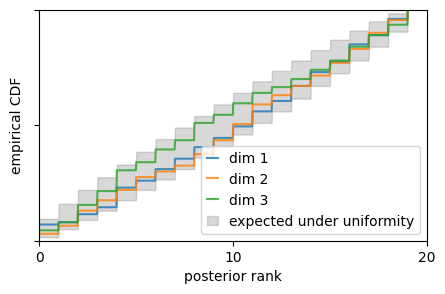

In [73]:
from sbi.diagnostics import run_sbc
from sbi.analysis.plot import sbc_rank_plot

# Obtain your `posterior_estimator` with NPE, NLE, NRE.

num_sbc_samples = 200  # choose a number of sbc runs, should be ~100s
prior_samples = prior_dist.sample((num_sbc_samples,))
prior_predictives = simulate(prior_samples)

# run SBC: for each inference we draw 1000 posterior samples.
num_posterior_samples = 5_000
ranks, dap_samples = run_sbc(
    prior_samples,
    prior_predictives,
    posterior,
    num_posterior_samples=num_posterior_samples,
    use_batched_sampling=False,  # `True` can give speed-ups, but can cause memory issues.
)
fig, ax = sbc_rank_plot(
    ranks,
    num_posterior_samples,
    num_bins=20,
    figsize=(5, 3),
)
